In [1]:
### Make notebook wider:

from IPython.display import display, HTML

display(HTML(data="""
<style>
    div#notebook-container    { width: 95%; }
    div#menubar-container     { width: 65%; }
    div#maintoolbar-container { width: 99%; }
</style>
"""))

In [2]:
def SaveFig(file_name,figure_dir):
    if not os.path.isdir(figure_dir):
        os.makedirs(figure_dir)
    plt.savefig(figure_dir + file_name, bbox_inches='tight')
    plt.show()
    plt.close()

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import re
import seaborn as sns;

# Dark_red = '#BE575F'
# Dark_blue = '#284194'

Dark_blue = '#D86F8C'
Dark_red = '#A8A5A5'

In [4]:
path = r"Z:\projects\Emmett\synthetic_data_rerun\synthetic_spikes\\"

data_paths = []
for animal in os.listdir(path):
    full_path = path + animal
    for file in os.listdir(full_path):
        if '.csv' in file:
            print(file)
            if not 'attempt' in file:
                data_paths += [os.path.join(full_path,file)]


for index,path in enumerate(data_paths):
    if index == 0:
        df = pd.read_csv(path)
    else:
        df_ = pd.read_csv(path)
        df = pd.concat([df,df_])
        


df = df.reset_index(drop=True)


decoder_path = r"Z:\projects\Benjamin\synthetic_analysis\\"

decoder_data_paths = []
for file in os.listdir(decoder_path):
    if file == 'total_duration_events.csv':
        total_duration_events = pd.read_csv(decoder_path + file)
        
    elif '.csv' in file:
        print(file)
        if not 'attempt' in file:
            decoder_data_paths += [decoder_path + file]
            
found_per_min = []
for file in os.listdir(decoder_path):
    if not '.csv' in file:
        try:
            total_events = len(np.load(decoder_path+file+ r'\synth_spikes\\' + 'event_periods.npy'))
            proportion_found = decoder_df[decoder_df.type == 'random_insertion'][decoder_df[decoder_df.type == 'random_insertion'].mouse_implant_recording == file].proportion_found.values[0]
            duration = total_duration_events[total_duration_events.ID == file].total_time.values[0]
            found_per_min += [(total_events*proportion_found)/duration]
        except:
            print(file)
            
for index,path in enumerate(decoder_data_paths):
    if not '148' in path:
        if index == 0:
            decoder_df = pd.read_csv(path)
        else:
            decoder_df_ = pd.read_csv(path)
            decoder_df = pd.concat([decoder_df,decoder_df_])
        
decoder_df = decoder_df.reset_index(drop=True)


path = r"Z:\projects\Ben_G\Decoding\decoder_results\\"
for ind, datafile in enumerate(os.listdir(path)):
    print(datafile)
    if ind == 0:
        decoder2_df = pd.read_csv(path + datafile, sep='\t', header=None, names=['mouse_implant_recording', 'type', 'proportion_found', 'proportion_mislabeled', 'false_positives_in_noise'])
    else:
        df2 = pd.read_csv(path + datafile, sep='\t', header=None, names=['mouse_implant_recording', 'type', 'proportion_found', 'proportion_mislabeled', 'false_positives_in_noise'])
        decoder2_df = decoder2_df.append(df2, ignore_index=True)

FileNotFoundError: [WinError 53] The network path was not found: 'Z:\\projects\\Emmett\\synthetic_data_rerun\\synthetic_spikes\\\\'

In [5]:
for mouse in df.mouse_implant_recording.unique():
    print('-------------------------')
    print(mouse)
    print(len(df[df.mouse_implant_recording == mouse]))
    print('missing:')
    for item in ["_standard_insertion","_background_noise_spikes_100","_background_noise_spikes_20","_background_noise_spikes_200","_background_noise_spikes_300","_background_noise_spikes_40","_background_noise_spikes_400","_background_noise_spikes_500","_background_noise_spikes_80","_backward_insertion","_disorered_spikes_10","_disorered_spikes_100","_disorered_spikes_20","_disorered_spikes_30","_disorered_spikes_40","_disorered_spikes_50","_disorered_spikes_60","_disorered_spikes_70","_disorered_spikes_80","_disorered_spikes_90","_dropped_spikes_1","_dropped_spikes_10","_dropped_spikes_15","_dropped_spikes_20","_dropped_spikes_30","_dropped_spikes_40","_dropped_spikes_5","_dropped_spikes_50","_dropped_spikes_60","_dropped_spikes_70","_dropped_spikes_80","_dropped_spikes_90","_warp_spikes_0.03","_warp_spikes_0.1","_warp_spikes_0.2","_warp_spikes_0.5","_warp_spikes_10","_warp_spikes_2","_warp_spikes_20","_warp_spikes_30","_warp_spikes_5"]:
        if not item in '_' + df[df.mouse_implant_recording == mouse].type.values :
            print(item)

-------------------------
136_1_3
41
missing:
-------------------------
148_2_2
41
missing:
-------------------------
149_1_1
41
missing:
-------------------------
178_1_6
41
missing:
-------------------------
178_1_7
41
missing:
-------------------------
178_2_1
41
missing:
-------------------------
178_2_2
41
missing:
-------------------------
178_2_3
41
missing:
-------------------------
178_2_4
41
missing:
-------------------------
255_1_2
41
missing:
-------------------------
262_1_5
41
missing:
-------------------------
269_1_2
41
missing:
-------------------------
270_1_3
41
missing:


# FP rate in blank noise

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# load in blank test data - it is in the dfs from the old test
old_data_path = "Z:\projects\Emmett\synthetic_data_rerun\old_data_non_column_insertion\\"
data_ = []
for file in os.listdir(old_data_path):
    old_df = pd.read_csv(old_data_path + file)
    data_ += [float(old_df[old_df.type == 'blank_test'].proportion_found.values/60)]    # /60, convert this to mins 
    
# load in fp data for decoder 2 - and convert to fps per min 
mouse_i_r = decoder2_df.mouse_implant_recording[decoder2_df.false_positives_in_noise.notna()].values
false_positives = decoder2_df.false_positives_in_noise[decoder2_df.false_positives_in_noise.notna()].values

permuted_attemps = []
total_lens = []
for path in r"Z:\projects\Emmett\synthetic_data_rerun\synthetic_spikes\\" + mouse_i_r +'\standard_insertion\\event_periods.npy':
    permuted_attemps += [len(np.load(path))]
    length_ = 0
    for i in range(len(np.load(path))):
        length_ += np.diff(np.load(path)[i])[0]
    total_lens += [length_]
total_fps_found = np.round(np.array(permuted_attemps) * false_positives)
total_fps_found_per_min = total_fps_found/total_lens

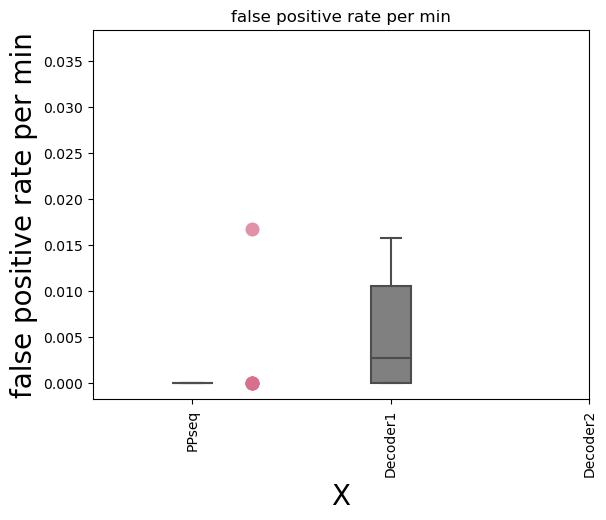

In [7]:
# Create figure and axes
fig, ax = plt.subplots()

# Plot jittered scatter plot
ax.plot(np.ones(len(data_))*0.3, data_, 'o',color=Dark_blue, alpha=0.5, label='Data',markeredgewidth=0,markersize = 10)
ax.plot(np.ones(len(found_per_min))*1.3, found_per_min, 'o',color=Dark_red, alpha=0.5, label='Data',markeredgewidth=0,markersize = 10)
ax.plot(np.ones(len(total_fps_found_per_min))*2.3, total_fps_found_per_min, 'o',color='blue', alpha=0.5, label='Data',markeredgewidth=0,markersize = 10)


data_lists = [data_, found_per_min, total_fps_found_per_min]

x_positions = [1, 2, 3]  # Define x positions for each box plot

# Create an empty list to store combined data
combined_data = []

# Combine data into a single list of tuples and align with x positions
for i, data in enumerate(data_lists):
    # Generate a list of tuples containing (x_position, value) pairs
    combined_data.extend([(x_positions[i], value) for value in data])

# Create DataFrame from combined data
combined_df = pd.DataFrame(combined_data, columns=["position", "value"])

# Create box plot
sns.boxplot(x="position", y="value", data=combined_df,width = 0.2, color = 'grey',showfliers=False)

# Set x-axis labels
plt.xticks(range(0, len(x_positions)), x_positions)



ax.set_xticklabels(('PPseq','Decoder1','Decoder2'), fontsize = 10,rotation='vertical')
ax.set_xlabel('',size = 20)
ax.set_ylabel('percentage found',size = 20)
ax.set_title('true_positives')



# Set labels and title
ax.set_xlabel('X')
ax.set_ylabel('false positive rate per min')
ax.set_title('false positive rate per min' )

SaveFig('false_positive.pdf',r'Z:\projects\Emmett\Documents\writeup\fig_synthetic_data\\')

# ax.set_ylim(0,100)

In [8]:
# stats 
import numpy as np
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn

# Perform Kruskal-Wallis test
kw_statistic, kw_pvalue = kruskal(data_lists[0], data_lists[1], data_lists[2])
print("Kruskal-Wallis Test:")
print("Statistic:", kw_statistic)
print("p-value:", kw_pvalue)

# Perform Dunn's test with Bonferroni correction as post hoc test
posthoc_results = posthoc_dunn([data_lists[0], data_lists[1], data_lists[2]], p_adjust="bonferroni")
print("\nDunn's Test (with Bonferroni correction):")
print(posthoc_results)


Kruskal-Wallis Test:
Statistic: nan
p-value: nan

Dunn's Test (with Bonferroni correction):
          1         3
1  1.000000  0.284035
3  0.284035  1.000000


# Standard insertion 

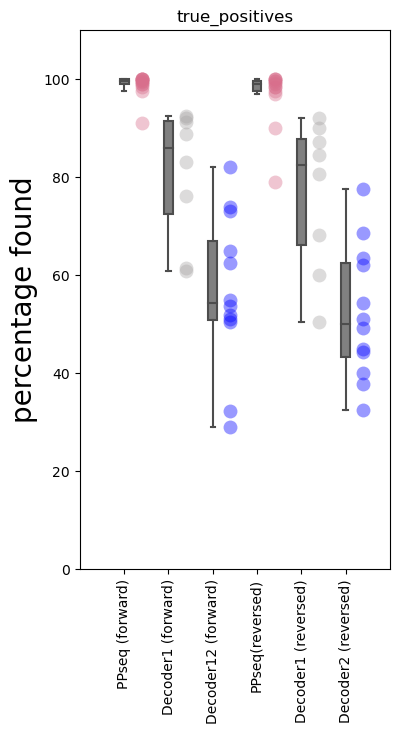

In [9]:
standard_insertion= df.proportion_found.values[np.where(df.type.values == 'standard_insertion')] *100
backwards_insertion = df.proportion_found.values[np.where(df.type.values == 'backward_insertion')] *100
mouse_standard_label= df[df.type == 'standard_insertion'].mouse_implant_recording.values

decoder_standard_insertion = list(decoder_df[decoder_df.type == 'standard_insertion'].proportion_found*100)
decoder_backwards_insertion = list(decoder_df[decoder_df.type == 'backwards_insertion'].proportion_found*100)
decoder_mouse_standard_label= decoder_df[decoder_df.type == 'standard_insertion'].mouse_implant_recording.values

decoder2_standard_insertion = list(decoder2_df[decoder2_df.type == 'standard_insertion'].proportion_found*100)
decoder2_backwards_insertion = list(decoder2_df[decoder2_df.type == 'backward_insertion'].proportion_found*100)
decoder2_mouse_standard_label= decoder2_df[decoder2_df.type == 'standard_insertion'].mouse_implant_recording.values

fig, ax= plt.subplots(1, 1,figsize=(4, 7))
ax.plot([0.4]*len(standard_insertion),standard_insertion,'o',alpha = 0.4, color = Dark_blue,markeredgewidth=0,markersize = 10)
ax.plot([3.4]*len(backwards_insertion),backwards_insertion,'o',alpha = 0.4, color = Dark_blue,markeredgewidth=0,markersize = 10)

ax.plot([1.4]*len(decoder_standard_insertion),decoder_standard_insertion,'o',alpha = 0.4, color = Dark_red,markeredgewidth=0,markersize = 10)
ax.plot([4.4]*len(decoder_backwards_insertion),decoder_backwards_insertion,'o',alpha = 0.4, color = Dark_red,markeredgewidth=0,markersize = 10)

ax.plot([2.4]*len(decoder2_standard_insertion),decoder2_standard_insertion,'o',alpha = 0.4, color = 'blue',markeredgewidth=0,markersize = 10)
ax.plot([5.4]*len(decoder2_backwards_insertion),decoder2_backwards_insertion,'o',alpha = 0.4, color = 'blue',markeredgewidth=0,markersize = 10)



data_lists = [standard_insertion, decoder_standard_insertion, decoder2_standard_insertion, backwards_insertion, decoder_backwards_insertion, decoder2_backwards_insertion]

x_positions = [1, 2, 3, 4, 5, 6]  # Define x positions for each box plot

# Create an empty list to store combined data
combined_data = []

# Combine data into a single list of tuples and align with x positions
for i, data in enumerate(data_lists):
    # Generate a list of tuples containing (x_position, value) pairs
    combined_data.extend([(x_positions[i], value) for value in data])

# Create DataFrame from combined data
combined_df = pd.DataFrame(combined_data, columns=["position", "value"])

# Create box plot
sns.boxplot(x="position", y="value", data=combined_df,width = 0.2, color = 'grey',showfliers=False)

# Set x-axis labels
plt.xticks(range(0, len(x_positions)), x_positions)



ax.set_xticklabels(('PPseq (forward)','Decoder1 (forward)','Decoder12 (forward)', 'PPseq(reversed)','Decoder1 (reversed)','Decoder2 (reversed)'), fontsize = 10,rotation='vertical')
ax.set_xlabel('',size = 20)
ax.set_ylabel('percentage found',size = 20)
ax.set_title('true_positives')


ax.set_ylim(0,110)
ax.set_xlim(-1,6)


SaveFig('percentage_found.pdf',r'Z:\projects\Emmett\Documents\writeup\fig_synthetic_data\\')

In [10]:
# stats 
import numpy as np
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn

print('------------------------------------------------')

# Perform Kruskal-Wallis test
kw_statistic, kw_pvalue = kruskal(data_lists[0], data_lists[1], data_lists[2])
print("Kruskal-Wallis Test:")
print("Statistic:", kw_statistic)
print("p-value:", kw_pvalue)

# Perform Dunn's test with Bonferroni correction as post hoc test
posthoc_results = posthoc_dunn([data_lists[0], data_lists[1], data_lists[2]], p_adjust="bonferroni")
print("\nDunn's Test (with Bonferroni correction):")
print(posthoc_results)

print('------------------------------------------------')

# Perform Kruskal-Wallis test
kw_statistic, kw_pvalue = kruskal(data_lists[3], data_lists[4], data_lists[5])
print("Kruskal-Wallis Test:")
print("Statistic:", kw_statistic)
print("p-value:", kw_pvalue)

# Perform Dunn's test with Bonferroni correction as post hoc test
posthoc_results = posthoc_dunn([data_lists[3], data_lists[4], data_lists[5]], p_adjust="bonferroni")
print("\nDunn's Test (with Bonferroni correction):")
print(posthoc_results)

------------------------------------------------
Kruskal-Wallis Test:
Statistic: 25.33360848853807
p-value: 3.154109840449551e-06

Dunn's Test (with Bonferroni correction):
          1         2         3
1  1.000000  0.028139  0.000002
2  0.028139  1.000000  0.199712
3  0.000002  0.199712  1.000000
------------------------------------------------
Kruskal-Wallis Test:
Statistic: 24.271951831409933
p-value: 5.363059649004156e-06

Dunn's Test (with Bonferroni correction):
          1         2         3
1  1.000000  0.041600  0.000003
2  0.041600  1.000000  0.178612
3  0.000003  0.178612  1.000000


In [11]:
# #### stats:
# from scipy.stats import mannwhitneyu
# from scipy.stats import ttest_ind
# from scipy.stats import ranksums
# import scipy
# scipy.stats.normaltest(standard_insertion)
# scipy.stats.normaltest(backwards_insertion)
# print('not normally distributed') 
# # non paramtetric t test
# # wilcoxn rank sum
# statistic, p_value = ranksums(standard_insertion, backwards_insertion)
# print('between ppseq forward and backward')
# print(p_value)


# #### stats:
# from scipy.stats import mannwhitneyu
# import scipy
# scipy.stats.normaltest(decoder_standard_insertion)
# scipy.stats.normaltest(decoder_backwards_insertion)
# print('normally distributed') 
# # non paramtetric t test
# statistic, p_value = ttest_ind(decoder_standard_insertion, decoder_backwards_insertion)
# print('between decoder forward and backward')
# print(p_value)


# statistic, p_value = ranksums(standard_insertion, decoder_standard_insertion)
# print('between PPseq adn decoder, forward')
# print(p_value)

# statistic, p_value = ranksums(backwards_insertion, decoder_backwards_insertion)
# print('between PPseq adn decoder, backwards')
# print(p_value)



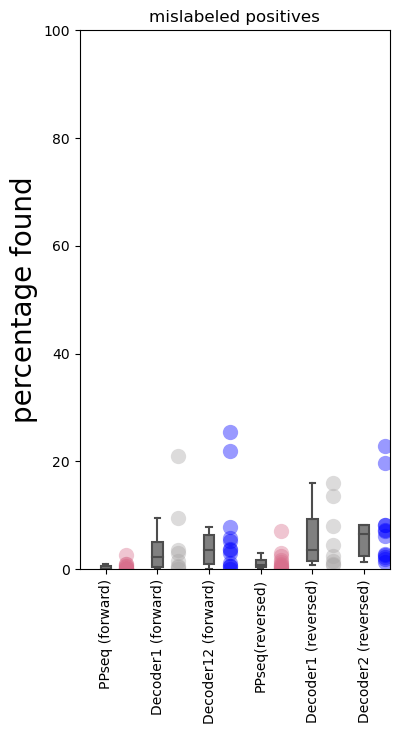

In [12]:
standard_insertion_mislabeled= df.proportion_mislabeled.values[np.where(df.type.values == 'standard_insertion')] *100
backwards_insertion_mislabeled = df.proportion_mislabeled.values[np.where(df.type.values == 'backward_insertion')] *100

decoder_standard_insertion_mislabeled = list(decoder_df[decoder_df.type == 'standard_insertion'].proportion_mislabeled*100)
decoder_backwards_insertion_mislabeled = list(decoder_df[decoder_df.type == 'backwards_insertion'].proportion_mislabeled*100)

decoder2_standard_insertion_mislabeled = list(decoder2_df[decoder2_df.type == 'standard_insertion'].proportion_mislabeled*100)
decoder2_backwards_insertion_mislabeled = list(decoder2_df[decoder2_df.type == 'backward_insertion'].proportion_mislabeled*100)



fig, ax= plt.subplots(1, 1,figsize=(4, 7))
ax.plot([0.4]*len(standard_insertion_mislabeled),standard_insertion_mislabeled,'o',alpha = 0.4, color = Dark_blue,markeredgewidth=0,markersize = 11)
ax.plot([3.4]*len(backwards_insertion_mislabeled),backwards_insertion_mislabeled,'o',alpha = 0.4, color = Dark_blue,markeredgewidth=0,markersize = 11)

ax.plot([1.4]*len(decoder_standard_insertion_mislabeled),decoder_standard_insertion_mislabeled,'o',alpha = 0.4, color = Dark_red,markeredgewidth=0,markersize = 11)
ax.plot([4.4]*len(decoder_backwards_insertion_mislabeled),decoder_backwards_insertion_mislabeled,'o',alpha = 0.4, color = Dark_red,markeredgewidth=0,markersize = 11)

ax.plot([2.4]*len(decoder2_standard_insertion_mislabeled),decoder2_standard_insertion_mislabeled,'o',alpha = 0.4, color = 'blue',markeredgewidth=0,markersize = 11)
ax.plot([5.4]*len(decoder2_backwards_insertion_mislabeled),decoder2_backwards_insertion_mislabeled,'o',alpha = 0.4, color = 'blue',markeredgewidth=0,markersize = 11)


data_lists = [standard_insertion_mislabeled, decoder_standard_insertion_mislabeled, decoder2_standard_insertion_mislabeled, backwards_insertion_mislabeled, decoder_backwards_insertion_mislabeled, decoder2_backwards_insertion_mislabeled]

x_positions = [1, 2, 3, 4, 5, 6]  # Define x positions for each box plot
# Create an empty list to store combined data
combined_data = []
# Combine data into a single list of tuples and align with x positions
for i, data in enumerate(data_lists):
    # Generate a list of tuples containing (x_position, value) pairs
    combined_data.extend([(x_positions[i], value) for value in data])
# Create DataFrame from combined data
combined_df = pd.DataFrame(combined_data, columns=["position", "value"])
# Create box plot
sns.boxplot(x="position", y="value", data=combined_df,width = 0.2, color = 'grey',showfliers=False)
# Set x-axis labels
plt.xticks(range(0, len(x_positions)), x_positions)


ax.set_xticklabels(('PPseq (forward)','Decoder1 (forward)','Decoder12 (forward)', 'PPseq(reversed)','Decoder1 (reversed)','Decoder2 (reversed)'), fontsize = 10,rotation='vertical')
ax.set_xlabel('',size = 20)
ax.set_ylabel('percentage found',size = 20)
ax.set_title('mislabeled positives')


ax.set_ylim(0,100)



SaveFig('mislablled.pdf',r'Z:\projects\Emmett\Documents\writeup\fig_synthetic_data\\')

In [13]:
# noemality tests
for i in range(6):
    try:
        print(scipy.stats.normaltest(data_lists[i]))
    except:
        print('not enough samples')


not enough samples
not enough samples
not enough samples
not enough samples
not enough samples
not enough samples


In [14]:
# stats 
import numpy as np
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn

print('------------------------------------------------')

# Perform Kruskal-Wallis test
kw_statistic, kw_pvalue = kruskal(data_lists[0], data_lists[1], data_lists[2])
print("Kruskal-Wallis Test:")
print("Statistic:", kw_statistic)
print("p-value:", kw_pvalue)

# Perform Dunn's test with Bonferroni correction as post hoc test
posthoc_results = posthoc_dunn([data_lists[0], data_lists[1], data_lists[2]], p_adjust="bonferroni")
print("\nDunn's Test (with Bonferroni correction):")
print(posthoc_results)

print('------------------------------------------------')

# Perform Kruskal-Wallis test
kw_statistic, kw_pvalue = kruskal(data_lists[3], data_lists[4], data_lists[5])
print("Kruskal-Wallis Test:")
print("Statistic:", kw_statistic)
print("p-value:", kw_pvalue)

# Perform Dunn's test with Bonferroni correction as post hoc test
posthoc_results = posthoc_dunn([data_lists[3], data_lists[4], data_lists[5]], p_adjust="bonferroni")
print("\nDunn's Test (with Bonferroni correction):")
print(posthoc_results)

------------------------------------------------
Kruskal-Wallis Test:
Statistic: 11.957183335082359
p-value: 0.0025323902293944585

Dunn's Test (with Bonferroni correction):
          1         2         3
1  1.000000  0.098866  0.002235
2  0.098866  1.000000  1.000000
3  0.002235  1.000000  1.000000
------------------------------------------------
Kruskal-Wallis Test:
Statistic: 13.122852167348647
p-value: 0.0014138679779201638

Dunn's Test (with Bonferroni correction):
          1        2         3
1  1.000000  0.05885  0.001382
2  0.058850  1.00000  1.000000
3  0.001382  1.00000  1.000000


In [15]:
# #### stats:

# import scipy
# scipy.stats.normaltest(decoder_backwards_insertion_mislabeled)
# scipy.stats.normaltest(decoder_standard_insertion_mislabeled)
# scipy.stats.normaltest(backwards_insertion_mislabeled)
# scipy.stats.normaltest(standard_insertion_mislabeled)
# print('not normally distributed') 


# statistic, p_value = ranksums(standard_insertion_mislabeled, backwards_insertion_mislabeled)
# print('between ppseq forward and backward')
# print(p_value)

# statistic, p_value = ranksums(decoder_standard_insertion_mislabeled, decoder_backwards_insertion_mislabeled)
# print('between decoder forward and backward')
# print(p_value)


# statistic, p_value = ranksums(standard_insertion_mislabeled, decoder_standard_insertion_mislabeled)
# print('between ppseq and decoder forward')
# print(p_value)

# statistic, p_value = ranksums(backwards_insertion_mislabeled, decoder_backwards_insertion_mislabeled)
# print('between ppseq and decoder backwards')
# print(p_value)

In [16]:
import scipy



def extract_data(df,type_label,mouse_standard_label,standard_insertion):

    #extract data properly into dfs: 
    number = []
    proportion = []
    mislabelled_proportion =[]
    mir = []
    current_type = type_label 
    for index,type_ in enumerate(df.type):    
        if current_type in type_:
            if not np.isnan(df.proportion_found[index]):
                number += [int(re.findall(r'\d+', type_)[0])]
                standard_found = standard_insertion[np.where(mouse_standard_label== df.mouse_implant_recording[index])[0][0]]
                proportion += [(df.proportion_found[index]*100)]
                mislabelled_proportion += [(df.proportion_mislabeled[index]*100)]
                mir += [df.mouse_implant_recording[index]]


    # sort these
    proportion = np.array(proportion)[np.argsort(number)]
    mislabelled_proportion = np.array(mislabelled_proportion)[np.argsort(number)]
    total_found = proportion 
    mir = np.array(mir)[np.argsort(number)]  
    number = np.array(number)[np.argsort(number)]    

    out_df = pd.DataFrame({'mir':mir,'number':number,'norm_total_found':total_found,'norm_mislabelled_proportion':mislabelled_proportion})
    
    return(out_df)

def calc_group_values(data,number):
    group_values = {}
    for value, group in zip(data, number):
        if group in group_values:
            group_values[group].append(value)
        else:
            group_values[group] = [value]
    group_means = {}
    group_std ={}
    for group, values in group_values.items():
        group_means[group] = np.mean(values)
        group_std[group] = scipy.stats.sem(values)
    print(group_means)
    return group_values,group_means,group_std

# Dropped Spikes insertion 

{1: 99.07208577974481, 5: 98.31480471552501, 10: 98.90173103930123, 15: 97.02205279568332, 20: 97.69787938886141, 30: 96.39050421172035, 40: 94.50421689158068, 50: 91.34600092299834, 60: 85.93326318070469, 70: 78.98488574664837, 80: 65.33646018142771, 90: 32.933718195163905}
{1: 0.5678738860783, 5: 0.467657558090317, 10: 0.49832661448777693, 15: 1.6140971704871714, 20: 1.019252157232294, 30: 0.8547446174221555, 40: 1.5238082503756138, 50: 2.309236794366777, 60: 3.5074094078742855, 70: 3.2057318347520973, 80: 4.907969437857087, 90: 7.434356172946981}
{0: 80.65465290320424, 1: 83.07383539408137, 5: 78.72234197461847, 10: 79.71683007941286, 15: 74.3226586465411, 20: 71.06545767514311, 30: 64.8038945509972, 40: 58.41092435368689, 50: 49.152444203147844, 60: 44.18264211414046, 70: 40.42757876781055, 80: 42.369715664210695, 90: 45.70914621618263}
{0: 5.020604579379409, 1: 2.7035171283042585, 5: 4.935462118823043, 10: 2.57396235636538, 15: 4.477799816996835, 20: 4.518519513966531, 30: 4.65949

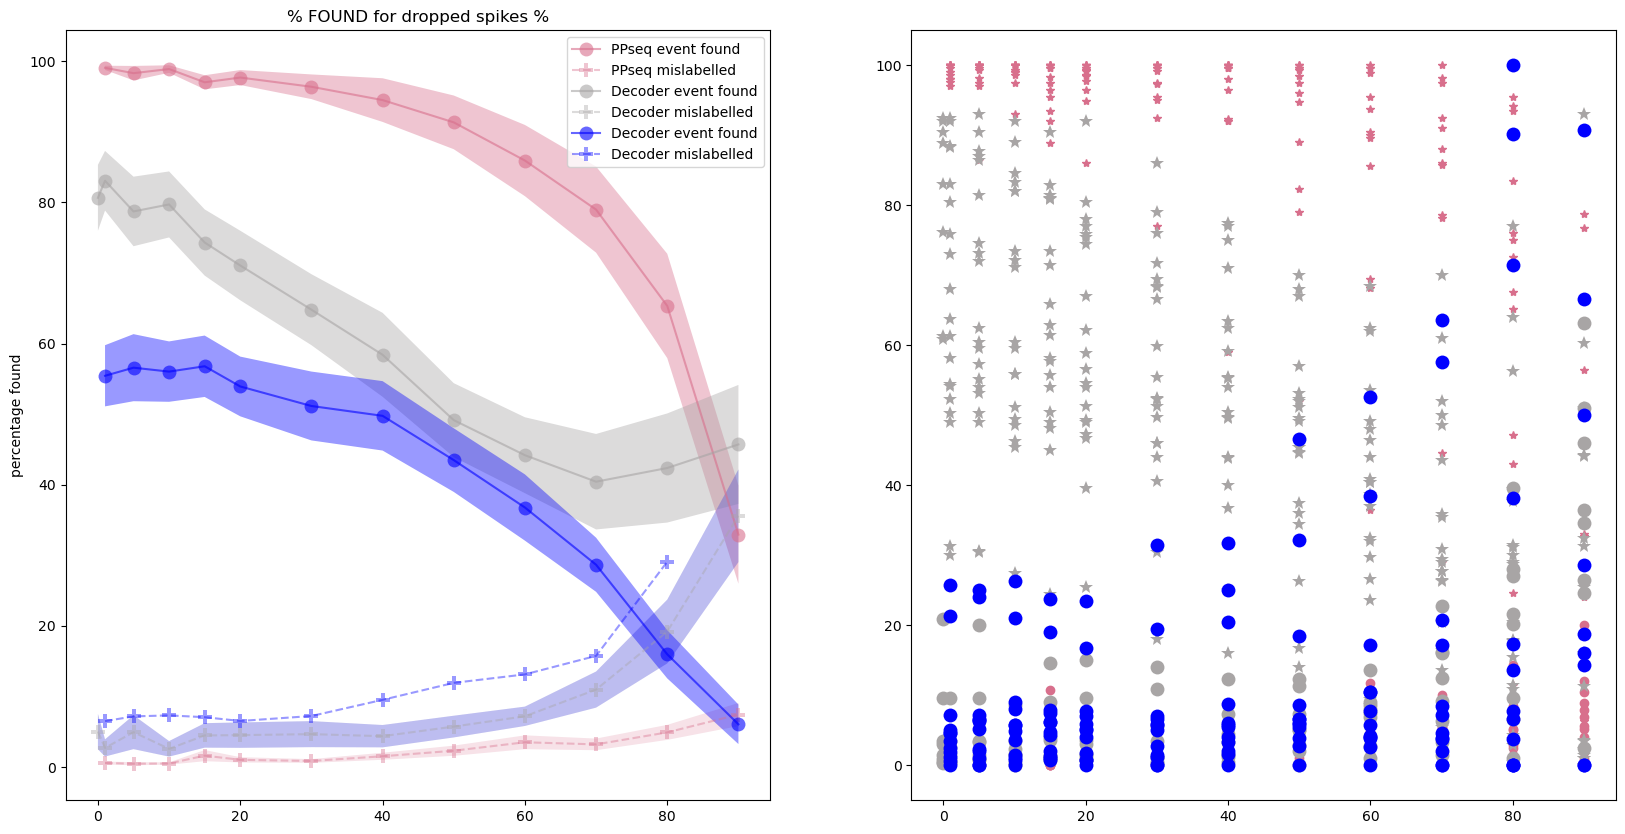

In [17]:
## load in data 

dropped_spikes_df = extract_data(df,'dropped_spikes',mouse_standard_label,standard_insertion)
decoder_dropped_spikes_df = extract_data(decoder_df,'dropped_spikes',decoder_mouse_standard_label,decoder_standard_insertion)
decoder2_dropped_spikes_df = extract_data(decoder2_df,'dropped_spikes',decoder2_mouse_standard_label,decoder2_standard_insertion)

group_values,group_means,group_std = calc_group_values(dropped_spikes_df.norm_total_found.values,dropped_spikes_df.number.values)
mislab_group_values,mislab_group_means,mislab_group_std = calc_group_values(dropped_spikes_df.norm_mislabelled_proportion.values,dropped_spikes_df.number.values)

# plot for ppseq:
fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))

ax.plot(group_means.keys(),group_means.values(), 'o-', color = Dark_blue, alpha = 0.6, label="PPseq event found",markeredgewidth=0,markersize = 10)
# ax.set_ylim(0,120)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.4, edgecolor='None', facecolor=Dark_blue,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'*',color = Dark_blue)
    
#mislablled:
ax.plot(mislab_group_means.keys(),mislab_group_means.values(), 'P--', color = Dark_blue, alpha = 0.4,label="PPseq mislabelled",markeredgewidth=0,markersize = 10)
# ax.set_ylim(0,120)

mislab_group_means_array = np.array(list(mislab_group_means.values()))
mislab_group_std_array = np.array(list(mislab_group_std.values()))
upper = mislab_group_means_array + mislab_group_std_array
lower = mislab_group_means_array - mislab_group_std_array
ax.fill_between(mislab_group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor=Dark_blue,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(mislab_group_values.keys()):
    y = list(mislab_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = Dark_blue)

    
### plot for decoder:
decoder_group_values,decoder_group_means,decoder_group_std = calc_group_values(decoder_dropped_spikes_df.norm_total_found.values,decoder_dropped_spikes_df.number.values)
decod_mislab_group_values,decod_mislab_group_means,decod_mislab_group_std = calc_group_values(decoder_dropped_spikes_df.norm_mislabelled_proportion.values,decoder_dropped_spikes_df.number.values)

ax.plot(decoder_group_means.keys(),decoder_group_means.values(), 'o-', color = Dark_red, alpha = 0.6,label="Decoder event found",markeredgewidth=0,markersize = 10)

decoder_group_means_array = np.array(list(decoder_group_means.values()))
decoder_group_std_array = np.array(list(decoder_group_std.values()))
upper = decoder_group_means_array + decoder_group_std_array
lower = decoder_group_means_array - decoder_group_std_array
ax.fill_between(decoder_group_means.keys(),(lower),(upper),
    alpha=0.4, edgecolor='None', facecolor=Dark_red,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decoder_group_values.keys()):
    y = list(decoder_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'*',color = Dark_red,markeredgewidth=0,markersize = 10)
    
#mislablled:

ax.plot(decod_mislab_group_means.keys(),decod_mislab_group_means.values(), 'P--', color = Dark_red, alpha = 0.4,label="Decoder mislabelled",markeredgewidth=0,markersize = 10)
# ax.set_ylim(0,120)

decod_mislab_group_means_array = np.array(list(decod_mislab_group_means.values()))
decod_mislab_group_std_array = np.array(list(decod_mislab_group_std.values()))
upper = decod_mislab_group_means_array + decod_mislab_group_std_array
lower = decod_mislab_group_means_array - decod_mislab_group_std_array
ax.fill_between(decod_mislab_group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor=Dark_red,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decod_mislab_group_values.keys()):
    y = list(decod_mislab_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = Dark_red,markeredgewidth=0,markersize = 10)
    
    

    
    
    
    
    
### plot for decoder:
decoder2_group_values,decoder2_group_means,decoder2_group_std = calc_group_values(decoder2_dropped_spikes_df.norm_total_found.values,decoder2_dropped_spikes_df.number.values)
decod2_mislab_group_values,decod2_mislab_group_means,decod2_mislab_group_std = calc_group_values(decoder2_dropped_spikes_df.norm_mislabelled_proportion.values,decoder2_dropped_spikes_df.number.values)

ax.plot(decoder2_group_means.keys(),decoder2_group_means.values(), 'o-', color = 'blue', alpha = 0.6,label="Decoder event found",markeredgewidth=0,markersize = 10)

decoder2_group_means_array = np.array(list(decoder2_group_means.values()))
decoder2_group_std_array = np.array(list(decoder2_group_std.values()))
upper = decoder2_group_means_array + decoder2_group_std_array
lower = decoder2_group_means_array - decoder2_group_std_array
ax.fill_between(decoder2_group_means.keys(),(lower),(upper),
    alpha=0.4, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decoder2_group_values.keys()):
    y = list(decoder2_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'*',color = Dark_red,markeredgewidth=0,markersize = 10)
    
#mislablled:

ax.plot(decod2_mislab_group_means.keys(),decod2_mislab_group_means.values(), 'P--', color = 'blue', alpha = 0.4,label="Decoder mislabelled",markeredgewidth=0,markersize = 10)
# ax.set_ylim(0,120)

decod2_mislab_group_means_array = np.array(list(decod_mislab_group_means.values()))
decod2_mislab_group_std_array = np.array(list(decod_mislab_group_std.values()))
upper = decod2_mislab_group_means_array + decod2_mislab_group_std_array
lower = decod2_mislab_group_means_array - decod2_mislab_group_std_array
ax.fill_between(decod_mislab_group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decod2_mislab_group_values.keys()):
    y = list(decod2_mislab_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'blue',markeredgewidth=0,markersize = 10)
 
    
    
ax.set_title('% FOUND for dropped spikes %')
ax.set_ylabel('percentage found')

ax.legend()

# ax.set_xlim(10,90)


SaveFig('dropped_spikes.pdf',r'Z:\projects\Emmett\Documents\writeup\fig_synthetic_data\\')

In [18]:
from skbio.stats.distance import permanova, DistanceMatrix
from skbio import DistanceMatrix
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import DistanceMatrix
from skbio.stats.distance import permanova
from itertools import combinations
from statsmodels.stats.multitest import multipletests

def replace_nans(list_of_lists):
    result = []
    for lst in list_of_lists:
        # Convert list to numpy array for ease of handling NaNs
        array = np.array(lst, dtype=np.float64)
        # Calculate mean of non-NaN values
        mean_value = np.nanmean(array)
        # Replace NaNs with the mean value
        array[np.isnan(array)] = mean_value
        # Convert back to list and append to result
        result.append(array.tolist())
    return result

def perform_permanova(data1,data2,data3):

    data1 = replace_nans(data1)
    data2 = replace_nans(data2)
    data3 = replace_nans(data3)

    stats_df = pd.DataFrame()

    longest_length1 = max(len(lst) for lst in data1)
    longest_length2 = max(len(lst) for lst in data2)
    longest_length3 = max(len(lst) for lst in data3)

    stats_df['groups'] = ['ppseq']*longest_length1  + ['decod1']*longest_length2 + ['decod2']*longest_length3



    for index,item in enumerate(data1):
        while len(data1[index]) < longest_length1:
            data1[index] += [np.mean(data1[index])]
        while len(data2[index]) < longest_length2:
            data2[index] += [np.mean(data2[index])]
        while len(data3[index]) < longest_length3:
            data3[index] += [np.mean(data3[index])]
        stats_df[str(index)] = data1[index] + data2[index] + data3[index]


    # Calculate the Euclidean distance matrix
    values = stats_df[list(stats_df)[1::]].values
    grouping = stats_df['groups'].values

    pairwise_distances = pdist(values, metric='euclidean')
    distance_matrix = squareform(pairwise_distances)
    dm = DistanceMatrix(distance_matrix)

    # Perform PERMANOVA
    results = permanova(dm, grouping, permutations=10000)
    print('-----------------')
    print(results)
    return dm, grouping,stats_df

def triplewise_permanova_by_feature(data, group_labels, method='bonferroni'):
    unique_groups = np.unique(group_labels)
    triplet_combinations = list(combinations(unique_groups, 3))
    feature_results = []
    feature_p_values = []

    num_features = data.shape[1]

    for feature_index in range(num_features):
        feature_data = data[:, feature_index]

        for group1, group2, group3 in triplet_combinations:
            mask = np.isin(group_labels, [group1, group2, group3])
            triplewise_feature_data = feature_data[mask]
            triplewise_group_labels = group_labels[mask]

            # Compute the distance matrix for the feature
            pairwise_distance_matrix = squareform(pdist(triplewise_feature_data[:, np.newaxis], metric='euclidean'))

            # Ensure the array is contiguous
            pairwise_distance_matrix = np.ascontiguousarray(pairwise_distance_matrix)

            # Create a DistanceMatrix object
            ids = np.arange(len(triplewise_group_labels))
            pairwise_distance_matrix = DistanceMatrix(pairwise_distance_matrix, ids)

            result = permanova(pairwise_distance_matrix, triplewise_group_labels, permutations=10000)
            feature_results.append((feature_index, group1, group2, group3, result))
            feature_p_values.append(result['p-value'])

    # Apply Bonferroni correction
    corrected_p_values = multipletests(feature_p_values, method=method)[1]

    # Update results with corrected p-values
    for i in range(len(feature_results)):
        feature_results[i][4]['p-value'] = corrected_p_values[i]

    return feature_results
    


def extract_data_for_stats(df_func,standard_insertion,standard_insertion_mislabeled):
    data1 = []
    data4 = []
    counter = 0
    for number, group in  df_func.groupby('number'):
        if counter == 0:
            if not number == 0:
                # if no standard add it back in
                data1 += [list(standard_insertion)]
                data4 += [list(standard_insertion_mislabeled)]
        data1 += [list(group.norm_total_found)]
        data4 += [list(group.norm_mislabelled_proportion)]
        counter +=1
    return data1, data4




In [19]:
# re extract th data:

df_= extract_data(df,'dropped_spikes',mouse_standard_label,standard_insertion)
decoder_df_ = extract_data(decoder_df,'dropped_spikes',decoder_mouse_standard_label,decoder_standard_insertion)
decoder2_df_ = extract_data(decoder2_df,'dropped_spikes',decoder2_mouse_standard_label,decoder2_standard_insertion)

data1, data4= extract_data_for_stats(df_,standard_insertion,standard_insertion_mislabeled)
data2, data5= extract_data_for_stats(decoder_df_,decoder_standard_insertion,decoder_standard_insertion_mislabeled)
data3, data6= extract_data_for_stats(decoder2_df_,decoder2_standard_insertion,decoder2_standard_insertion_mislabeled)
    
    
## test for normality

from scipy.stats import shapiro

for items in [data1,data2,data3,data4,data5,data6]:
    for item in items:
        if shapiro(item)[1] < 0.05:
            print(shapiro(item)[1])
            print('use non p')
            break
            
            
    
## test for normality

from scipy.stats import shapiro

for items in [data1,data2,data3,data4,data5,data6]:
    for item in items:
        if shapiro(item)[1] < 0.05:
            print(shapiro(item)[1])
            print('use non p')
            break
            
            
### non paramteric, use permanova:
dm, grouping,stats_df = perform_permanova(data1,data2,data3)


## do pairwise permanova

all_features = []
for item in list(stats_df)[1::]:
    all_features += [list(stats_df[item])]

feature_results = triplewise_permanova_by_feature(stats_df[list(stats_df)[1::]].values, np.array(grouping))


print("Feature-wise Triplewise Results:")
for feature_index, group1, group2, group3, result in feature_results:
    if result['p-value'] < 0.05:
        print('^^^^^^^^^^^^^^^^^^^^^^')
        print(f"Feature {feature_index} / {len(all_features)-1}: Comparison: {group1}, {group2}, {group3}")
        print(f"P-value (corrected): {result['p-value']}")
        print(result)
        if result['p-value'] < 0.001:
            print('***')
        elif result['p-value'] < 0.01:
            print('**')
        else:
            print('*')
        print('______')
        
    
print('===================================== MISLABELLED ============================')


            
### non paramteric, use permanova:
dm, grouping,stats_df = perform_permanova(data4,data5,data6)


## do pairwise permanova

all_features = []
for item in list(stats_df)[1::]:
    all_features += [list(stats_df[item])]

feature_results = triplewise_permanova_by_feature(stats_df[list(stats_df)[1::]].values, np.array(grouping))


print("Feature-wise Triplewise Results:")
for feature_index, group1, group2, group3, result in feature_results:
    if result['p-value'] < 0.05:
        print('^^^^^^^^^^^^^^^^^^^^^^')
        print(f"Feature {feature_index} / {len(all_features)-1}: Comparison: {group1}, {group2}, {group3}")
        print(f"P-value (corrected): {result['p-value']}")
        print(result)
        if result['p-value'] < 0.001:
            print('***')
        elif result['p-value'] < 0.01:
            print('**')
        else:
            print('*')
        print('______')
        

2.870483513106592e-05
use non p
0.0470551997423172
use non p
0.0004916671314276755
use non p
0.00044750081724487245
use non p
0.0031575991306453943
use non p
0.0015594273572787642
use non p
2.870483513106592e-05
use non p
0.0470551997423172
use non p
0.0004916671314276755
use non p
0.00044750081724487245
use non p
0.0031575991306453943
use non p
0.0015594273572787642
use non p
-----------------
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      33
number of groups                  3
test statistic            29.730637
p-value                      0.0001
number of permutations        10000
Name: PERMANOVA results, dtype: object
Feature-wise Triplewise Results:
^^^^^^^^^^^^^^^^^^^^^^
Feature 0 / 12: Comparison: decod1, decod2, ppseq
P-value (corrected): 0.0012998700129987003
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      33
number of groups                  3
test statistic    

In [20]:
# def stars(p):  
#     stars = []
#     if p < 0.05 and p > 0.01:
#         stars+=['*']
#     elif p < 0.01 and p > 0.001:
#         stars+=['**']
#     elif p < 0.001:
#         stars+=['***']
#     elif p > 0.05:
#         stars+=['ns']
#     return(stars)

# def stats_test(data1,data2,data3):
    
#     for i in range(len(data1)):
#         s,p1 = scipy.stats.shapiro(data1[i])
#         s,p2 = scipy.stats.shapiro(data2[i])
#         s,p3 = scipy.stats.shapiro(data3[i])
        
#     _stars = []
#     _p = []
#     s,p__ = scipy.stats.kruskal(*(data1 + data2 + data3))
#     print(p__)
    
#     groups = []
#     labels = ['ppseq_','d1_','d2_']
#     for i,data in enumerate([data1,data2,data3]):
#         print(len(data))
#         for index,item in enumerate(data):
#             groups+=[labels[i]+str(index)]*len(item)
#     data_df = pd.DataFrame({'values': [item for sublist in (data1 + data2 + data3) for item in sublist], 'groups': groups})
#     dunn_results = sp.posthoc_dunn(data_df, val_col='values', group_col='groups')
    
#     all_ps = []
#     for i in range(len(data1)):
#         d1_p = dunn_results['ppseq_' + str(i)]['d1_'+str(i)]
#         d2_p = dunn_results['ppseq_' + str(i)]['d2_'+str(i)]

#         _stars += [[i+1, stars(d1_p),stars(d2_p)]]
#         if d1_p < 0.05:
#             d1_str = str(d1_p)
#             if d1_p < 0.001:
#                 all_ps += ['p < 0.001']
#             else:
#                 all_ps += ['p = ' + str(round(d1_p, 5))]
#         else:
#             d1_str = '----'
#         if d2_p < 0.05:
#             d2_str = str(d2_p)
#             if d2_p < 0.001:
#                 all_ps += ['p < 0.001']
#             else:
#                 all_ps += ['p = ' + str(round(d2_p, 5))]
#         else:
#             d2_str = '----'
#         _p += [[i+1,d1_str,d2_str]]
        
        
#     print(_stars)
#     print(_p)
#     return _stars,_p, all_ps


# df_= extract_data(df,'dropped_spikes',mouse_standard_label,standard_insertion)
# decoder_df_ = extract_data(decoder_df,'dropped_spikes',decoder_mouse_standard_label,decoder_standard_insertion)
# decoder2_df_ = extract_data(decoder2_df,'dropped_spikes',decoder2_mouse_standard_label,decoder2_standard_insertion)

# ### if no group 0 then add the standard! 

# data1 = []
# data4 = []
# counter = 0
# for number, group in  df_.groupby('number'):
#     if counter == 0:
#         if not number == 0:
#             data1 += [list(standard_insertion)]
#             data4 += [list(standard_insertion_mislabeled)]
#     data1 += [list(group.norm_total_found)]
#     data4 += [list(group.norm_mislabelled_proportion)]
#     counter +=1
    
# data2 = []
# data5 = []
# counter = 0
# for number, group in  decoder_df_.groupby('number'):
#     if counter == 0:
#         if not number == 0:
#             data2 += [decoder_standard_insertion]
#             data5 += [decoder_standard_insertion_mislabeled]
#     data2 += [list(group.norm_total_found)]
#     data5 += [list(group.norm_mislabelled_proportion)]
#     counter +=1
    
# data3 = []
# data6 = []
# counter = 0
# for number, group in  decoder2_df_.groupby('number'):
#     if counter == 0:
#         if not number == 0:
#             data3 += [decoder2_standard_insertion]
#             data6 += [decoder2_standard_insertion_mislabeled]
#     data3 += [list(group.norm_total_found)]
#     data6 += [list(group.norm_mislabelled_proportion)]
#     counter +=1
    
    
# from statsmodels.stats.multicomp import pairwise_tukeyhsd
# import scikit_posthocs as sp
    
# stars1,ps1,easy_ps1 = stats_test(data1,data2,data3)    
# stars2,ps2,easy_ps2 = stats_test(data4,data5,data6)    


# with open("D:\\easy_ps1.txt", "w") as file:
#     # Step 3: Write each item of the list to the file
#     file.write(", ".join(easy_ps1))
    

# with open("D:\\easy_ps2.txt", "w") as file:
#     # Step 3: Write each item of the list to the file
#     file.write(", ".join(easy_ps2))


# Background noise insertion 

{20: 96.54973589853799, 40: 92.27913012774539, 80: 83.43606507145878, 100: 78.2415073405975, 200: 62.093028590445435, 300: 42.6811139518885, 400: 37.1518497973599, 500: 28.8755811854794}
{20: 1.987505564261357, 40: 5.251825939209047, 80: 8.402809048153408, 100: 9.373562479385457, 200: 13.482253398777821, 300: 20.865622438282756, 400: 27.38502024944995, 500: 37.1773959298741}
{0: 80.65465290320424, 20: 53.605017774719755, 40: 50.06191885744866, 80: 57.959289560696845, 100: 58.75415042095506, 200: 44.56986103943885, 300: 38.71542500453924, 400: 37.20899271809868, 500: 34.94227158051661}
{0: 5.02060457937941, 20: 5.48294917003526, 40: 9.089565833357222, 80: 26.79264529161052, 100: 34.374128584807394, 200: 55.26121760413979, 300: 61.28457499546076, 400: 62.79100728190133, 500: 65.05772841948338}
{20: 15.462458333333332, 40: 6.363908333333332, 80: 2.4876666666666662, 100: 2.2285166666666667, 200: 7.481525, 300: 9.921725, 400: 13.39335, 500: 12.2005}
{20: 8.297616666666665, 40: 12.7501666666

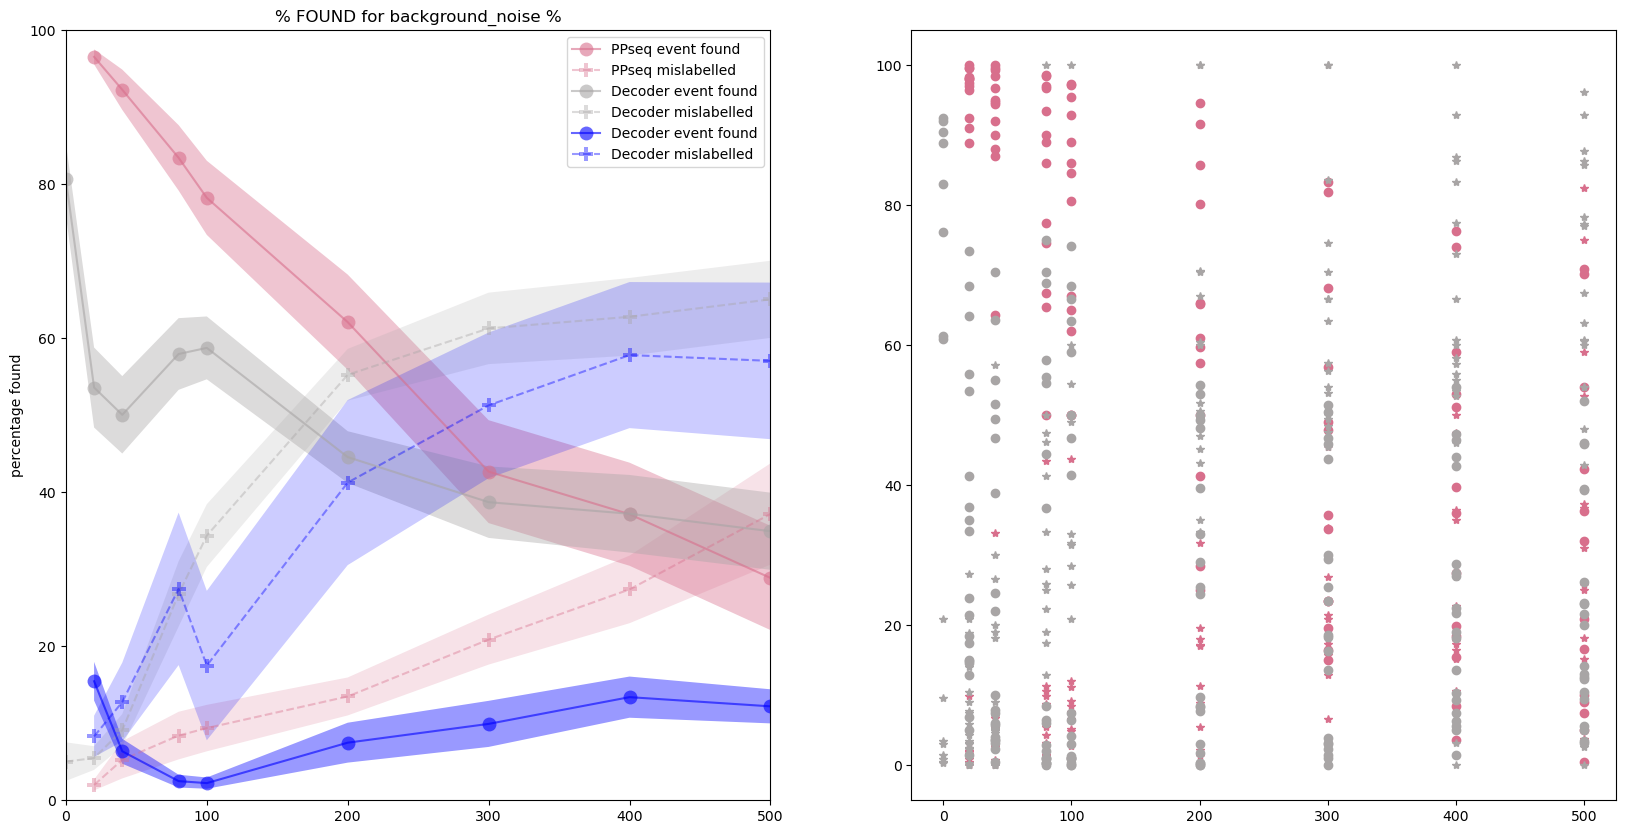

In [21]:
## load in data 

dropped_spikes_df = extract_data(df,'background_noise',mouse_standard_label,standard_insertion)
decoder_dropped_spikes_df = extract_data(decoder_df,'background_noise',decoder_mouse_standard_label,decoder_standard_insertion)
decoder2_dropped_spikes_df = extract_data(decoder2_df,'background_noise',decoder2_mouse_standard_label,decoder2_standard_insertion)
decoder2_dropped_spikes_df.fillna(0, inplace=True)

group_values,group_means,group_std = calc_group_values(dropped_spikes_df.norm_total_found.values,dropped_spikes_df.number.values)
mislab_group_values,mislab_group_means,mislab_group_std = calc_group_values(dropped_spikes_df.norm_mislabelled_proportion.values,dropped_spikes_df.number.values)

# plot for ppseq:
fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))

ax.plot(group_means.keys(),group_means.values(), 'o-', color = Dark_blue, alpha = 0.6, label="PPseq event found",markeredgewidth=0,markersize = 10)
# ax.set_ylim(0,120)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.4, edgecolor='None', facecolor=Dark_blue,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = Dark_blue)
    
#mislablled:
ax.plot(mislab_group_means.keys(),mislab_group_means.values(), 'P--', color = Dark_blue, alpha = 0.4,label="PPseq mislabelled",markeredgewidth=0,markersize = 10)
# ax.set_ylim(0,120)

mislab_group_means_array = np.array(list(mislab_group_means.values()))
mislab_group_std_array = np.array(list(mislab_group_std.values()))
upper = mislab_group_means_array + mislab_group_std_array
lower = mislab_group_means_array - mislab_group_std_array
ax.fill_between(mislab_group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor=Dark_blue,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(mislab_group_values.keys()):
    y = list(mislab_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'*',color = Dark_blue)

    
### plot for decoder:
decoder_group_values,decoder_group_means,decoder_group_std = calc_group_values(decoder_dropped_spikes_df.norm_total_found.values,decoder_dropped_spikes_df.number.values)
decod_mislab_group_values,decod_mislab_group_means,decod_mislab_group_std = calc_group_values(decoder_dropped_spikes_df.norm_mislabelled_proportion.values,decoder_dropped_spikes_df.number.values)

ax.plot(decoder_group_means.keys(),decoder_group_means.values(), 'o-', color = Dark_red, alpha = 0.6,label="Decoder event found",markeredgewidth=0,markersize = 10)

decoder_group_means_array = np.array(list(decoder_group_means.values()))
decoder_group_std_array = np.array(list(decoder_group_std.values()))
upper = decoder_group_means_array + decoder_group_std_array
lower = decoder_group_means_array - decoder_group_std_array
ax.fill_between(decoder_group_means.keys(),(lower),(upper),
    alpha=0.4, edgecolor='None', facecolor=Dark_red,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decoder_group_values.keys()):
    y = list(decoder_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = Dark_red)
    
#mislablled:

ax.plot(decod_mislab_group_means.keys(),decod_mislab_group_means.values(),  'P--', color = Dark_red, alpha = 0.4,label="Decoder mislabelled",markeredgewidth=0,markersize = 10)
# ax.set_ylim(0,120)

decod_mislab_group_means_array = np.array(list(decod_mislab_group_means.values()))
decod_mislab_group_std_array = np.array(list(decod_mislab_group_std.values()))
upper = decod_mislab_group_means_array + decod_mislab_group_std_array
lower = decod_mislab_group_means_array - decod_mislab_group_std_array
ax.fill_between(decod_mislab_group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor=Dark_red,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decod_mislab_group_values.keys()):
    y = list(decod_mislab_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'*',color = Dark_red)
    
    
### plot for decoder2:
decoder_group_values,decoder_group_means,decoder_group_std = calc_group_values(decoder2_dropped_spikes_df.norm_total_found.values,decoder2_dropped_spikes_df.number.values)
decod_mislab_group_values,decod_mislab_group_means,decod_mislab_group_std = calc_group_values(decoder2_dropped_spikes_df.norm_mislabelled_proportion.values,decoder2_dropped_spikes_df.number.values)

ax.plot(decoder_group_means.keys(),decoder_group_means.values(), 'o-', color = 'blue', alpha = 0.6,label="Decoder event found",markeredgewidth=0,markersize = 10)

decoder_group_means_array = np.array(list(decoder_group_means.values()))
decoder_group_std_array = np.array(list(decoder_group_std.values()))
upper = decoder_group_means_array + decoder_group_std_array
lower = decoder_group_means_array - decoder_group_std_array
ax.fill_between(decoder_group_means.keys(),(lower),(upper),
    alpha=0.4, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decoder_group_values.keys()):
    y = list(decoder_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = Dark_red)
    
#mislablled:

ax.plot(decod_mislab_group_means.keys(),decod_mislab_group_means.values(),  'P--', color = 'blue', alpha = 0.4,label="Decoder mislabelled",markeredgewidth=0,markersize = 10)
# ax.set_ylim(0,120)

decod_mislab_group_means_array = np.array(list(decod_mislab_group_means.values()))
decod_mislab_group_std_array = np.array(list(decod_mislab_group_std.values()))
upper = decod_mislab_group_means_array + decod_mislab_group_std_array
lower = decod_mislab_group_means_array - decod_mislab_group_std_array
ax.fill_between(decod_mislab_group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decod_mislab_group_values.keys()):
    y = list(decod_mislab_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'*',color = Dark_red)

    
    
ax.set_title('% FOUND for background_noise %')
ax.set_ylabel('percentage found')

ax.legend()

ax.set_ylim(0,100)
ax.set_xlim(0,500)

SaveFig('background_noise.pdf',r'Z:\projects\Emmett\Documents\writeup\fig_synthetic_data\\')

In [22]:
# re extract th data:

df_= extract_data(df,'background_noise',mouse_standard_label,standard_insertion)
decoder_df_ = extract_data(decoder_df,'background_noise',decoder_mouse_standard_label,decoder_standard_insertion)
decoder2_df_ = extract_data(decoder2_df,'background_noise',decoder2_mouse_standard_label,decoder2_standard_insertion)

data1, data4= extract_data_for_stats(df_,standard_insertion,standard_insertion_mislabeled)
data2, data5= extract_data_for_stats(decoder_df_,decoder_standard_insertion,decoder_standard_insertion_mislabeled)
data3, data6= extract_data_for_stats(decoder2_df_,decoder2_standard_insertion,decoder2_standard_insertion_mislabeled)
    
    
## test for normality

from scipy.stats import shapiro

for items in [data1,data2,data3,data4,data5,data6]:
    for item in items:
        if shapiro(item)[1] < 0.05:
            print(shapiro(item)[1])
            print('use non p')
            break
            
            
    
## test for normality

from scipy.stats import shapiro

for items in [data1,data2,data3,data4,data5,data6]:
    for item in items:
        if shapiro(item)[1] < 0.05:
            print(shapiro(item)[1])
            print('use non p')
            break
            
            
### non paramteric, use permanova:
dm, grouping,stats_df = perform_permanova(data1,data2,data3)


## do pairwise permanova

all_features = []
for item in list(stats_df)[1::]:
    all_features += [list(stats_df[item])]

feature_results = triplewise_permanova_by_feature(stats_df[list(stats_df)[1::]].values, np.array(grouping))


print("Feature-wise Triplewise Results:")
for feature_index, group1, group2, group3, result in feature_results:
    if result['p-value'] < 0.05:
        print('^^^^^^^^^^^^^^^^^^^^^^')
        print(f"Feature {feature_index} / {len(all_features)-1}: Comparison: {group1}, {group2}, {group3}")
        print(f"P-value (corrected): {result['p-value']}")
        print(result)
        if result['p-value'] < 0.001:
            print('***')
        elif result['p-value'] < 0.01:
            print('**')
        else:
            print('*')
        print('______')
        
    
print('===================================== MISLABELLED ============================')


            
### non paramteric, use permanova:
dm, grouping,stats_df = perform_permanova(data4,data5,data6)


## do pairwise permanova

all_features = []
for item in list(stats_df)[1::]:
    all_features += [list(stats_df[item])]

feature_results = triplewise_permanova_by_feature(stats_df[list(stats_df)[1::]].values, np.array(grouping))


print("Feature-wise Triplewise Results:")
for feature_index, group1, group2, group3, result in feature_results:
    if result['p-value'] < 0.05:
        print('^^^^^^^^^^^^^^^^^^^^^^')
        print(f"Feature {feature_index} / {len(all_features)-1}: Comparison: {group1}, {group2}, {group3}")
        print(f"P-value (corrected): {result['p-value']}")
        print(result)
        if result['p-value'] < 0.001:
            print('***')
        elif result['p-value'] < 0.01:
            print('**')
        else:
            print('*')
        print('______')
        

2.870483513106592e-05
use non p
0.0470551997423172
use non p
0.005123020149767399
use non p
0.00044750081724487245
use non p
0.0031575991306453943
use non p
0.0015594273572787642
use non p
2.870483513106592e-05
use non p
0.0470551997423172
use non p
0.005123020149767399
use non p
0.00044750081724487245
use non p
0.0031575991306453943
use non p
0.0015594273572787642
use non p
-----------------
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      33
number of groups                  3
test statistic            59.413396
p-value                      0.0001
number of permutations        10000
Name: PERMANOVA results, dtype: object
Feature-wise Triplewise Results:
^^^^^^^^^^^^^^^^^^^^^^
Feature 0 / 8: Comparison: decod1, decod2, ppseq
P-value (corrected): 0.0008999100089991002
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      33
number of groups                  3
test statistic       

In [23]:
# df_= extract_data(df,'background_noise',mouse_standard_label,standard_insertion)
# decoder_df_ = extract_data(decoder_df,'background_noise',decoder_mouse_standard_label,decoder_standard_insertion)
# decoder2_df_ = extract_data(decoder2_df,'background_noise',decoder2_mouse_standard_label,decoder2_standard_insertion)

# ### if no group 0 then add the standard! 

# data1 = []
# data4 = []
# counter = 0
# for number, group in  df_.groupby('number'):
#     if counter == 0:
#         if not number == 0:
#             data1 += [list(standard_insertion)]
#             data4 += [list(standard_insertion_mislabeled)]
#     data1 += [list(group.norm_total_found)]
#     data4 += [list(group.norm_mislabelled_proportion)]
#     counter +=1
    
# data2 = []
# data5 = []
# counter = 0
# for number, group in  decoder_df_.groupby('number'):
#     if counter == 0:
#         if not number == 0:
#             data2 += [decoder_standard_insertion]
#             data5 += [decoder_standard_insertion_mislabeled]
#     data2 += [list(group.norm_total_found)]
#     data5 += [list(group.norm_mislabelled_proportion)]
#     counter +=1
    
# data3 = []
# data6 = []
# counter = 0
# for number, group in  decoder2_df_.groupby('number'):
#     if counter == 0:
#         if not number == 0:
#             data3 += [decoder2_standard_insertion]
#             data6 += [decoder2_standard_insertion_mislabeled]
#     data3 += [list(group.norm_total_found)]
#     data6 += [list(group.norm_mislabelled_proportion)]
#     counter +=1
    
    
# stars1,ps1,easy_ps1 = stats_test(data1,data2,data3)    
# stars2,ps2,easy_ps2 = stats_test(data4,data5,data6)    


# with open("D:\\easy_ps1.txt", "w") as file:
#     # Step 3: Write each item of the list to the file
#     file.write(", ".join(easy_ps1))
    

# with open("D:\\easy_ps2.txt", "w") as file:
#     # Step 3: Write each item of the list to the file
#     file.write(", ".join(easy_ps2))

# misordered insertion 

{10: 96.6555198973731, 20: 97.02114733066544, 30: 94.83897762515765, 40: 96.5399988818907, 50: 91.56980552520832, 60: 86.83927549343561, 70: 80.71750821617528, 80: 81.16370061094206, 90: 78.2336110221566, 100: 74.88137210264804}
{10: 1.6977767055071202, 20: 0.6294271655303584, 30: 2.647017264795625, 40: 1.6034670161655478, 50: 2.941680665290958, 60: 5.113681805933633, 70: 7.880847994664398, 80: 7.8874247970007065, 90: 7.638122633085711, 100: 7.928312060367667}
{0: 80.65465290320422, 10: 77.9486195240689, 20: 72.27346878195388, 30: 69.50962080597843, 40: 66.09018938199401, 50: 64.22277589040834, 60: 62.540496019800656, 70: 63.482557958965245, 80: 63.470146414475884, 90: 63.46899219250213, 100: 62.64203858595415}
{0: 5.02060457937941, 10: 3.2780132723368256, 20: 4.75159321454851, 30: 4.800130264327283, 40: 4.905469369666387, 50: 4.567605155146544, 60: 5.022752955286065, 70: 4.699390726087744, 80: 5.51961460632818, 90: 5.953462008925582, 100: 6.398105045249082}
{10: 51.482916666666675, 20

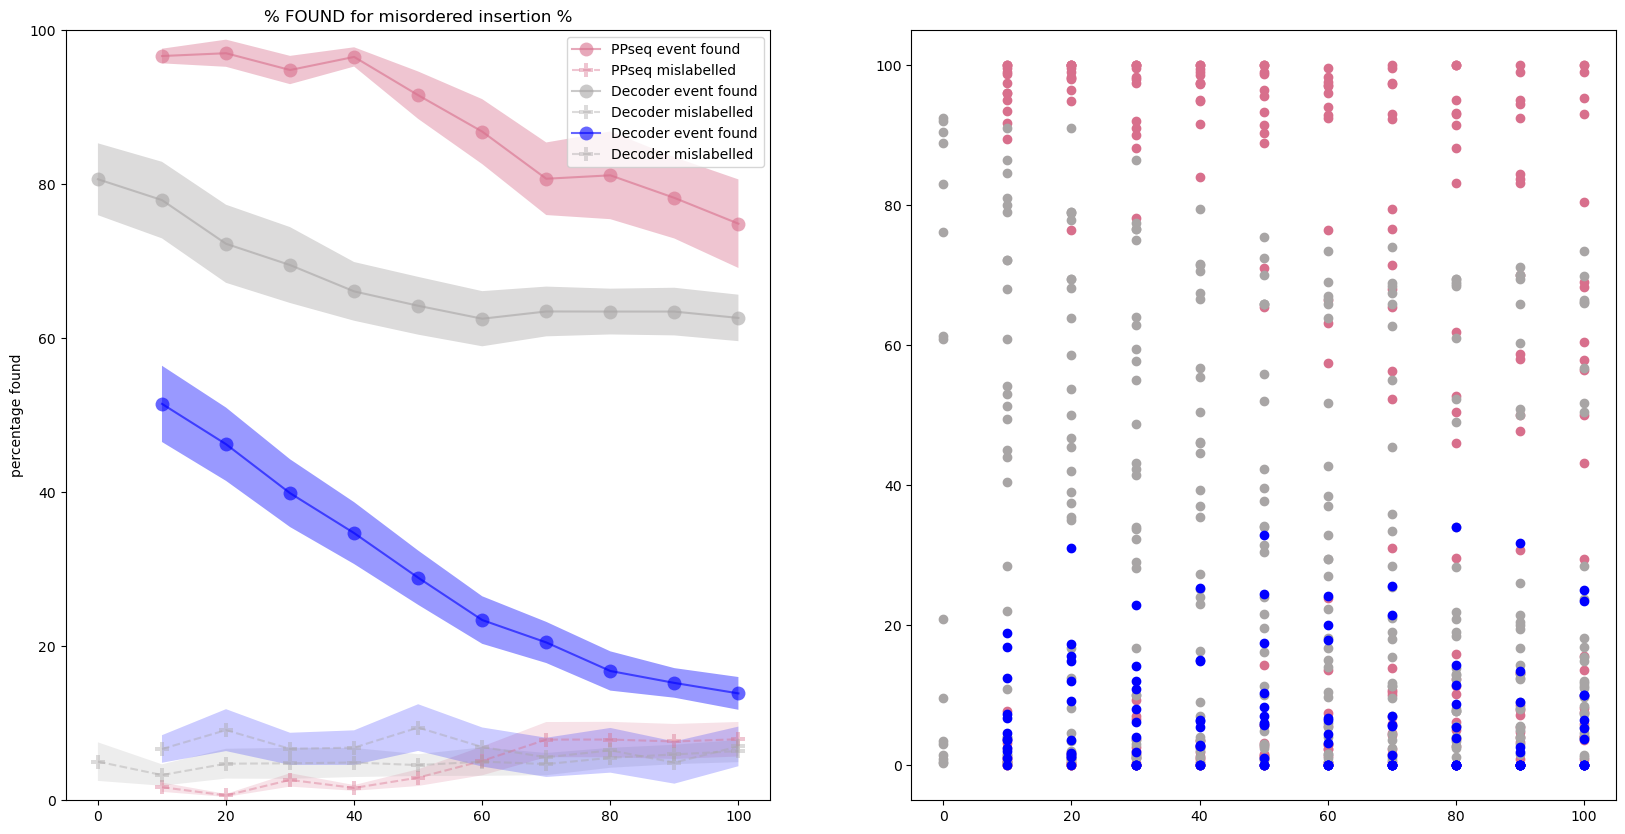

In [24]:
## load in data 

dropped_spikes_df = extract_data(df,'disorered_spikes',mouse_standard_label,standard_insertion)
decoder_dropped_spikes_df = extract_data(decoder_df,'swapped_spikes',decoder_mouse_standard_label,decoder_standard_insertion)
decoder2_dropped_spikes_df = extract_data(decoder2_df,'disorered_spikes',decoder2_mouse_standard_label,decoder2_standard_insertion)


group_values,group_means,group_std = calc_group_values(dropped_spikes_df.norm_total_found.values,dropped_spikes_df.number.values)
mislab_group_values,mislab_group_means,mislab_group_std = calc_group_values(dropped_spikes_df.norm_mislabelled_proportion.values,dropped_spikes_df.number.values)

# plot for ppseq:
fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))

ax.plot(group_means.keys(),group_means.values(), 'o-', color = Dark_blue, alpha = 0.6, label="PPseq event found",markeredgewidth=0,markersize = 10)
# ax.set_ylim(0,120)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.4, edgecolor='None', facecolor=Dark_blue,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = Dark_blue)
    
#mislablled:
ax.plot(mislab_group_means.keys(),mislab_group_means.values(), 'P--', color = Dark_blue, alpha = 0.4,label="PPseq mislabelled",markeredgewidth=0,markersize = 10)
# ax.set_ylim(0,120)

mislab_group_means_array = np.array(list(mislab_group_means.values()))
mislab_group_std_array = np.array(list(mislab_group_std.values()))
upper = mislab_group_means_array + mislab_group_std_array
lower = mislab_group_means_array - mislab_group_std_array
ax.fill_between(mislab_group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor=Dark_blue,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(mislab_group_values.keys()):
    y = list(mislab_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = Dark_blue)

    
### plot for decoder:
decoder_group_values,decoder_group_means,decoder_group_std = calc_group_values(decoder_dropped_spikes_df.norm_total_found.values,decoder_dropped_spikes_df.number.values)
decod_mislab_group_values,decod_mislab_group_means,decod_mislab_group_std = calc_group_values(decoder_dropped_spikes_df.norm_mislabelled_proportion.values,decoder_dropped_spikes_df.number.values)

ax.plot(decoder_group_means.keys(),decoder_group_means.values(), 'o-', color = Dark_red, alpha = 0.6,label="Decoder event found",markeredgewidth=0,markersize = 10)

decoder_group_means_array = np.array(list(decoder_group_means.values()))
decoder_group_std_array = np.array(list(decoder_group_std.values()))
upper = decoder_group_means_array + decoder_group_std_array
lower = decoder_group_means_array - decoder_group_std_array
ax.fill_between(decoder_group_means.keys(),(lower),(upper),
    alpha=0.4, edgecolor='None', facecolor=Dark_red,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decoder_group_values.keys()):
    y = list(decoder_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = Dark_red)
    
#mislablled:

ax.plot(decod_mislab_group_means.keys(),decod_mislab_group_means.values(), 'P--', color = Dark_red, alpha = 0.4,label="Decoder mislabelled",markeredgewidth=0,markersize = 10)
# ax.set_ylim(0,120)

decod_mislab_group_means_array = np.array(list(decod_mislab_group_means.values()))
decod_mislab_group_std_array = np.array(list(decod_mislab_group_std.values()))
upper = decod_mislab_group_means_array + decod_mislab_group_std_array
lower = decod_mislab_group_means_array - decod_mislab_group_std_array
ax.fill_between(decod_mislab_group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor=Dark_red,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decod_mislab_group_values.keys()):
    y = list(decod_mislab_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = Dark_red)
    
    
    
### plot for decoder2:
decoder_group_values,decoder_group_means,decoder_group_std = calc_group_values(decoder2_dropped_spikes_df.norm_total_found.values,decoder2_dropped_spikes_df.number.values)
decod_mislab_group_values,decod_mislab_group_means,decod_mislab_group_std = calc_group_values(decoder2_dropped_spikes_df.norm_mislabelled_proportion.values,decoder2_dropped_spikes_df.number.values)

ax.plot(decoder_group_means.keys(),decoder_group_means.values(), 'o-', color = 'blue', alpha = 0.6,label="Decoder event found",markeredgewidth=0,markersize = 10)

decoder_group_means_array = np.array(list(decoder_group_means.values()))
decoder_group_std_array = np.array(list(decoder_group_std.values()))
upper = decoder_group_means_array + decoder_group_std_array
lower = decoder_group_means_array - decoder_group_std_array
ax.fill_between(decoder_group_means.keys(),(lower),(upper),
    alpha=0.4, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decoder_group_values.keys()):
    y = list(decoder_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = Dark_red)
    
#mislablled:

ax.plot(decod_mislab_group_means.keys(),decod_mislab_group_means.values(), 'P--', color = Dark_red, alpha = 0.4,label="Decoder mislabelled",markeredgewidth=0,markersize = 10)
# ax.set_ylim(0,120)

decod_mislab_group_means_array = np.array(list(decod_mislab_group_means.values()))
decod_mislab_group_std_array = np.array(list(decod_mislab_group_std.values()))
upper = decod_mislab_group_means_array + decod_mislab_group_std_array
lower = decod_mislab_group_means_array - decod_mislab_group_std_array
ax.fill_between(decod_mislab_group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decod_mislab_group_values.keys()):
    y = list(decod_mislab_group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'blue')

    
    
ax.set_title('% FOUND for misordered insertion %')
ax.set_ylabel('percentage found')

ax.legend()

ax.set_ylim(0,100)
# ax.set_xlim(20,100)

SaveFig('misordered.pdf',r'Z:\projects\Emmett\Documents\writeup\fig_synthetic_data\\')

In [25]:
# re extract th data:

df_= extract_data(df,'disorered_spikes',mouse_standard_label,standard_insertion)
decoder_df_ = extract_data(decoder_df,'swapped_spikes',decoder_mouse_standard_label,decoder_standard_insertion)
decoder2_df_ = extract_data(decoder2_df,'disorered_spikes',decoder2_mouse_standard_label,decoder2_standard_insertion)

data1, data4= extract_data_for_stats(df_,standard_insertion,standard_insertion_mislabeled)
data2, data5= extract_data_for_stats(decoder_df_,decoder_standard_insertion,decoder_standard_insertion_mislabeled)
data3, data6= extract_data_for_stats(decoder2_df_,decoder2_standard_insertion,decoder2_standard_insertion_mislabeled)
    
    
## test for normality

from scipy.stats import shapiro

for items in [data1,data2,data3,data4,data5,data6]:
    for item in items:
        if shapiro(item)[1] < 0.05:
            print(shapiro(item)[1])
            print('use non p')
            break
            
            
    
## test for normality

from scipy.stats import shapiro

for items in [data1,data2,data3,data4,data5,data6]:
    for item in items:
        if shapiro(item)[1] < 0.05:
            print(shapiro(item)[1])
            print('use non p')
            break
            
            
### non paramteric, use permanova:
dm, grouping,stats_df = perform_permanova(data1,data2,data3)


## do pairwise permanova

all_features = []
for item in list(stats_df)[1::]:
    all_features += [list(stats_df[item])]

feature_results = triplewise_permanova_by_feature(stats_df[list(stats_df)[1::]].values, np.array(grouping))


print("Feature-wise Triplewise Results:")
for feature_index, group1, group2, group3, result in feature_results:
    if result['p-value'] < 0.05:
        print('^^^^^^^^^^^^^^^^^^^^^^')
        print(f"Feature {feature_index} / {len(all_features)-1}: Comparison: {group1}, {group2}, {group3}")
        print(f"P-value (corrected): {result['p-value']}")
        print(result)
        if result['p-value'] < 0.001:
            print('***')
        elif result['p-value'] < 0.01:
            print('**')
        else:
            print('*')
        print('______')
        
    
print('===================================== MISLABELLED ============================')


            
### non paramteric, use permanova:
dm, grouping,stats_df = perform_permanova(data4,data5,data6)


## do pairwise permanova

all_features = []
for item in list(stats_df)[1::]:
    all_features += [list(stats_df[item])]

feature_results = triplewise_permanova_by_feature(stats_df[list(stats_df)[1::]].values, np.array(grouping))


print("Feature-wise Triplewise Results:")
for feature_index, group1, group2, group3, result in feature_results:
    if result['p-value'] < 0.05:
        print('^^^^^^^^^^^^^^^^^^^^^^')
        print(f"Feature {feature_index} / {len(all_features)-1}: Comparison: {group1}, {group2}, {group3}")
        print(f"P-value (corrected): {result['p-value']}")
        print(result)
        if result['p-value'] < 0.001:
            print('***')
        elif result['p-value'] < 0.01:
            print('**')
        else:
            print('*')
        print('______')
        

2.870483513106592e-05
use non p
0.0470551997423172
use non p
0.00044750081724487245
use non p
0.0031575991306453943
use non p
0.0015594273572787642
use non p
2.870483513106592e-05
use non p
0.0470551997423172
use non p
0.00044750081724487245
use non p
0.0031575991306453943
use non p
0.0015594273572787642
use non p
-----------------
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      33
number of groups                  3
test statistic            66.616222
p-value                      0.0001
number of permutations        10000
Name: PERMANOVA results, dtype: object
Feature-wise Triplewise Results:
^^^^^^^^^^^^^^^^^^^^^^
Feature 0 / 10: Comparison: decod1, decod2, ppseq
P-value (corrected): 0.0010998900109989002
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      33
number of groups                  3
test statistic            40.969321
p-value                      0.0011
number of 

In [26]:
# df_= extract_data(df,'disorered_spikes',mouse_standard_label,standard_insertion)
# decoder_df_ = extract_data(decoder_df,'swapped_spikes',decoder_mouse_standard_label,decoder_standard_insertion)
# decoder2_df_ = extract_data(decoder2_df,'disorered_spikes',decoder2_mouse_standard_label,decoder2_standard_insertion)

# ### if no group 0 then add the standard! 

# data1 = []
# data4 = []
# counter = 0
# for number, group in  df_.groupby('number'):
#     if counter == 0:
#         if not number == 0:
#             data1 += [list(standard_insertion)]
#             data4 += [list(standard_insertion_mislabeled)]
#     data1 += [list(group.norm_total_found)]
#     data4 += [list(group.norm_mislabelled_proportion)]
#     counter +=1
    
# data2 = []
# data5 = []
# counter = 0
# for number, group in  decoder_df_.groupby('number'):
#     if counter == 0:
#         if not number == 0:
#             data2 += [decoder_standard_insertion]
#             data5 += [decoder_standard_insertion_mislabeled]
#     data2 += [list(group.norm_total_found)]
#     data5 += [list(group.norm_mislabelled_proportion)]
#     counter +=1
    
# data3 = []
# data6 = []
# counter = 0
# for number, group in  decoder2_df_.groupby('number'):
#     if counter == 0:
#         if not number == 0:
#             data3 += [decoder2_standard_insertion]
#             data6 += [decoder2_standard_insertion_mislabeled]
#     data3 += [list(group.norm_total_found)]
#     data6 += [list(group.norm_mislabelled_proportion)]
#     counter +=1
    
    
# stars1,ps1,easy_ps1 = stats_test(data1,data2,data3)    
# stars2,ps2,easy_ps2 = stats_test(data4,data5,data6)    


# with open("D:\\easy_ps1.txt", "w") as file:
#     # Step 3: Write each item of the list to the file
#     file.write(", ".join(easy_ps1))
    

# with open("D:\\easy_ps2.txt", "w") as file:
#     # Step 3: Write each item of the list to the file
#     file.write(", ".join(easy_ps2))

In [27]:
decoder2_df.proportion_mislabeled

0      0.000000
1      0.000000
2      0.000000
3      0.000000
4      0.090909
         ...   
487    0.125000
488    0.000000
489    0.000000
490    0.000000
491    0.166670
Name: proportion_mislabeled, Length: 492, dtype: float64

# WARP insertion

In [28]:
def extract_data_warp(df,mouse_standard_label,standard_insertion_mislabeled, standard_insertion):

    #extract data properly into dfs: 
    number = []
    proportion = []
    mislabelled_proportion =[]
    mir = []
    current_type = 'warp' 
    for index,type_ in enumerate(df.type):
        if current_type in type_:
            if not np.isnan(df.proportion_found[index]):
                proportion += [(df.proportion_found[index]*100)]
                mislabelled_proportion += [(df.proportion_mislabeled[index]*100)]
                mir += [df.mouse_implant_recording[index]]
                try:
                    number += [float(re.findall(r'\d+\.\d+', type_)[0])]
                    if float(re.findall(r'\d+\.\d+', type_)[0]) == 0.1:
                        print(df.mouse_implant_recording[index])
                except:
                    number += [int(re.findall(r'\d+', type_)[0])]
                    
    number += [1]*len(standard_insertion)
    proportion += list(standard_insertion)
    mislabelled_proportion += list(standard_insertion_mislabeled)
    mir += list(mouse_standard_label)

    # sort these
    proportion = np.array(proportion)[np.argsort(number)]
    mislabelled_proportion = np.array(mislabelled_proportion)[np.argsort(number)]
    total_found = proportion 
    mir = np.array(mir)[np.argsort(number)]  
    number = np.array(number)[np.argsort(number)]    

    out_df = pd.DataFrame({'mir':mir,'number':number,'norm_total_found':total_found,'norm_mislabelled_proportion':mislabelled_proportion})
    
    return(out_df)




136_1_3
148_2_2
149_1_1
178_1_6
178_1_7
178_2_1
178_2_2
178_2_3
178_2_4
255_1_2
262_1_5
269_1_2
270_1_3
136_1_3
149_1_1
178_1_6
178_1_7
178_2_1
178_2_3
178_2_4
269_1_2
136_1_3
149_1_1
178_1_6
178_1_7
178_2_1
178_2_2
178_2_3
178_2_4
255_1_2
262_1_5
269_1_2
270_1_3
{0.03: 70.1923076923077, 0.1: 59.30769230769231, 0.2: 87.34615384615384, 0.5: 76.11538461538461, 1.0: 98.72847856692246, 2.0: 89.0, 5.0: 81.92307692307692, 10.0: 62.417582416483505, 20.0: 21.28205127692308, 30.0: 11.538461538461538}
{0.03: 4.042689353474718, 0.1: 13.473893383089994, 0.2: 3.4023061011165576, 0.5: 8.937829853108989, 1.0: 0.4828168686925477, 2.0: 1.9989744302098649, 5.0: 3.791644457867334, 10.0: 9.364959189270028, 20.0: 29.586144845883936, 30.0: 7.179487176923076}
{0.03: 82.5, 0.1: 88.6875, 0.2: 87.25, 0.5: 86.125, 1.0: 80.7588195698709, 2.0: 75.28600330003022, 5.0: 56.87807054134223, 10.0: 50.21922280617933, 20.0: 44.25620931571009, 30.0: 38.54797979797979}
{0.03: 16.4375, 0.1: 9.4375, 0.2: 8.125, 0.5: 6.5, 1.0:

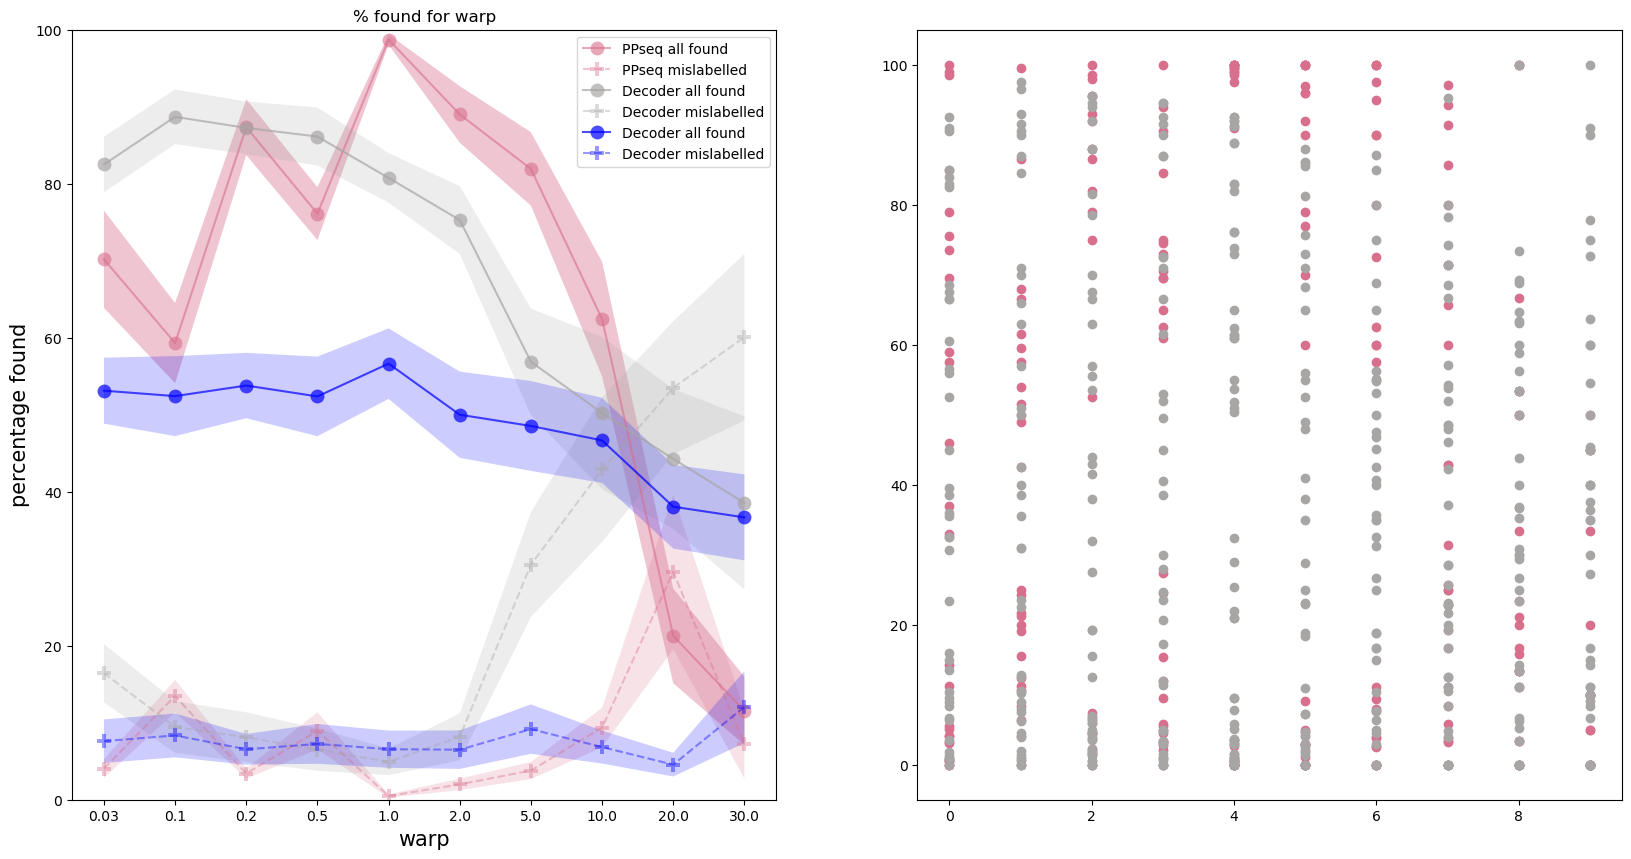

In [29]:
warp_spikes_df = extract_data_warp(df,mouse_standard_label,standard_insertion_mislabeled,standard_insertion)
decod_warp_spikes_df = extract_data_warp(decoder_df,mouse_standard_label,decoder_standard_insertion_mislabeled,decoder_standard_insertion)
decod2_warp_spikes_df = extract_data_warp(decoder2_df,mouse_standard_label,decoder2_standard_insertion_mislabeled,decoder2_standard_insertion)

decod2_warp_spikes_df.fillna(0, inplace=True)

group_values,group_means,group_std = calc_group_values(warp_spikes_df.norm_total_found.values,warp_spikes_df.number.values)
mislab_group_values,mislab_group_means,mislab_group_std = calc_group_values(warp_spikes_df.norm_mislabelled_proportion.values,warp_spikes_df.number.values)


fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))

labels = list(np.sort(np.unique(warp_spikes_df.number.values)).astype(str))
ax.set_xticks(range(0,len(labels)))
ax.set_xticklabels(labels)

x_val = np.sort(list(range(0,len(np.unique(labels)))) * len(np.where(warp_spikes_df.number.values == np.unique(warp_spikes_df.number.values)[0])[0]))
# ax.plot(x_val,normalised_proportion, 'o', color = 'grey')
ax.plot(np.sort(list(range(0,len(np.unique(labels))))),group_means.values(), 'o-', color = Dark_blue, alpha = 0.6,label="PPseq all found",markeredgewidth=0,markersize = 10)


group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(np.sort(list(range(0,len(np.unique(labels))))),(lower),(upper),
    alpha=0.4, edgecolor='None', facecolor=Dark_blue,
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [np.sort(list(range(0,len(np.unique(labels)))))[i]]*len(y)
    ax2.plot(x_,y,'o',color = Dark_blue)
    
     
# mislabelled      
labels = list(np.sort(np.unique(warp_spikes_df.number.values)).astype(str))
ax.set_xticks(range(0,len(labels)))
ax.set_xticklabels(labels)

x_val = np.sort(list(range(0,len(np.unique(labels)))) * len(np.where(warp_spikes_df.number.values == np.unique(warp_spikes_df.number.values)[0])[0]))
# ax.plot(x_val,normalised_proportion, 'o', color = 'grey')
ax.plot(np.sort(list(range(0,len(np.unique(labels))))),mislab_group_means.values(), 'P--', color = Dark_blue, alpha = 0.4,label="PPseq mislabelled",markeredgewidth=0,markersize = 10)


mislab_group_means_array = np.array(list(mislab_group_means.values()))
mislab_group_std_array = np.array(list(mislab_group_std.values()))
upper = mislab_group_means_array + mislab_group_std_array
lower = mislab_group_means_array - mislab_group_std_array
ax.fill_between(np.sort(list(range(0,len(np.unique(labels))))),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor=Dark_blue,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(mislab_group_values.keys()):
    y = list(mislab_group_values.values())[i]
    x_ = [np.sort(list(range(0,len(np.unique(labels)))))[i]]*len(y)
    ax2.plot(x_,y,'o',color = Dark_blue)
        
        
        
        
        
# decoder:        
        
decod_group_values,decod_group_means,decod_group_std = calc_group_values(decod_warp_spikes_df.norm_total_found.values,decod_warp_spikes_df.number.values)
decod_mislab_group_values,decod_mislab_group_means,decod_mislab_group_std = calc_group_values(decod_warp_spikes_df.norm_mislabelled_proportion.values,decod_warp_spikes_df.number.values)


labels = list(np.sort(np.unique(decod_warp_spikes_df.number.values)).astype(str))
ax.set_xticks(range(0,len(labels)))
ax.set_xticklabels(labels)

x_val = np.sort(list(range(0,len(np.unique(decod_warp_spikes_df.number.values)))) * len(np.where(decod_warp_spikes_df.number.values == np.unique(decod_warp_spikes_df.number.values)[0])[0]))
# ax.plot(x_val,normalised_proportion, 'o', color = 'grey')
ax.plot(np.sort(list(range(0,len(np.unique(labels))))),decod_group_means.values(), 'o-', color = Dark_red, alpha = 0.7,label="Decoder all found",markeredgewidth=0,markersize = 10)


decod_group_means_array = np.array(list(decod_group_means.values()))
decod_group_std_array = np.array(list(decod_group_std.values()))
upper = decod_group_means_array + decod_group_std_array
lower = decod_group_means_array - decod_group_std_array
ax.fill_between(np.sort(list(range(0,len(np.unique(labels))))),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor=Dark_red,
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(decod_group_values.keys()):
    y = list(decod_group_values.values())[i]
    x_ = [np.sort(list(range(0,len(np.unique(labels)))))[i]]*len(y)
    ax2.plot(x_,y,'o',color = Dark_red)

    
# mislabelled      
labels = list(np.sort(np.unique(warp_spikes_df.number.values)).astype(str))
ax.set_xticks(range(0,len(labels)))
ax.set_xticklabels(labels)

x_val = np.sort(list(range(0,len(np.unique(labels)))) * len(np.where(warp_spikes_df.number.values == np.unique(warp_spikes_df.number.values)[0])[0]))
# ax.plot(x_val,normalised_proportion, 'o', color = 'grey')
ax.plot(np.sort(list(range(0,len(np.unique(labels))))),decod_mislab_group_means.values(), 'P--', color = Dark_red, alpha = 0.4,label="Decoder mislabelled",markeredgewidth=0,markersize = 10)


decod_mislab_group_means_array = np.array(list(decod_mislab_group_means.values()))
decod_mislab_group_std_array = np.array(list(decod_mislab_group_std.values()))
upper = decod_mislab_group_means_array + decod_mislab_group_std_array
lower = decod_mislab_group_means_array - decod_mislab_group_std_array
ax.fill_between(np.sort(list(range(0,len(np.unique(labels))))),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor=Dark_red,
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decod_mislab_group_values.keys()):
    y = list(decod_mislab_group_values.values())[i]
    x_ = [np.sort(list(range(0,len(np.unique(labels)))))[i]]*len(y)
    ax2.plot(x_,y,'o',color = Dark_red)
    
    
    
    
# decoder2:        
        
decod_group_values,decod_group_means,decod_group_std = calc_group_values(decod2_warp_spikes_df.norm_total_found.values,decod2_warp_spikes_df.number.values)
decod_mislab_group_values,decod_mislab_group_means,decod_mislab_group_std = calc_group_values(decod2_warp_spikes_df.norm_mislabelled_proportion.values,decod2_warp_spikes_df.number.values)


labels = list(np.sort(np.unique(decod_warp_spikes_df.number.values)).astype(str))
ax.set_xticks(range(0,len(labels)))
ax.set_xticklabels(labels)

x_val = np.sort(list(range(0,len(np.unique(decod_warp_spikes_df.number.values)))) * len(np.where(decod_warp_spikes_df.number.values == np.unique(decod_warp_spikes_df.number.values)[0])[0]))
# ax.plot(x_val,normalised_proportion, 'o', color = 'grey')
ax.plot(np.sort(list(range(0,len(np.unique(labels))))),decod_group_means.values(), 'o-', color = 'blue', alpha = 0.7,label="Decoder all found",markeredgewidth=0,markersize = 10)


decod_group_means_array = np.array(list(decod_group_means.values()))
decod_group_std_array = np.array(list(decod_group_std.values()))
upper = decod_group_means_array + decod_group_std_array
lower = decod_group_means_array - decod_group_std_array
ax.fill_between(np.sort(list(range(0,len(np.unique(labels))))),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(decod_group_values.keys()):
    y = list(decod_group_values.values())[i]
    x_ = [np.sort(list(range(0,len(np.unique(labels)))))[i]]*len(y)
    ax2.plot(x_,y,'o',color = Dark_red)

    
# mislabelled      
labels = list(np.sort(np.unique(warp_spikes_df.number.values)).astype(str))
ax.set_xticks(range(0,len(labels)))
ax.set_xticklabels(labels)

x_val = np.sort(list(range(0,len(np.unique(labels)))) * len(np.where(warp_spikes_df.number.values == np.unique(warp_spikes_df.number.values)[0])[0]))
# ax.plot(x_val,normalised_proportion, 'o', color = 'grey')
ax.plot(np.sort(list(range(0,len(np.unique(labels))))),decod_mislab_group_means.values(), 'P--', color = 'blue', alpha = 0.4,label="Decoder mislabelled",markeredgewidth=0,markersize = 10)


decod_mislab_group_means_array = np.array(list(decod_mislab_group_means.values()))
decod_mislab_group_std_array = np.array(list(decod_mislab_group_std.values()))
upper = decod_mislab_group_means_array + decod_mislab_group_std_array
lower = decod_mislab_group_means_array - decod_mislab_group_std_array
ax.fill_between(np.sort(list(range(0,len(np.unique(labels))))),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(decod_mislab_group_values.keys()):
    y = list(decod_mislab_group_values.values())[i]
    x_ = [np.sort(list(range(0,len(np.unique(labels)))))[i]]*len(y)
    ax2.plot(x_,y,'o',color = Dark_red)
    
    
    
            
ax.set_ylim(0,100)
# ax.set_xlim(20,100)
    

ax.set_title('% found for warp')

ax.legend()

ax.set_ylabel('percentage found',size = 15)
ax.set_xlabel('warp',size = 15)

# SaveFig('warp.pdf',r'Z:\projects\Emmett\Documents\writeup\fig_synthetic_data\\')

SaveFig('warp.pdf',r'D:\\')

In [30]:
# re extract th data:

warp_spikes_df = extract_data_warp(df,mouse_standard_label,standard_insertion_mislabeled,standard_insertion)
decod_warp_spikes_df = extract_data_warp(decoder_df,mouse_standard_label,decoder_standard_insertion_mislabeled,decoder_standard_insertion)
decod2_warp_spikes_df = extract_data_warp(decoder2_df,mouse_standard_label,decoder2_standard_insertion_mislabeled,decoder2_standard_insertion)


data1, data4= extract_data_for_stats(df_,standard_insertion,standard_insertion_mislabeled)
data2, data5= extract_data_for_stats(decoder_df_,decoder_standard_insertion,decoder_standard_insertion_mislabeled)
data3, data6= extract_data_for_stats(decoder2_df_,decoder2_standard_insertion,decoder2_standard_insertion_mislabeled)
    
    
## test for normality

from scipy.stats import shapiro

for items in [data1,data2,data3,data4,data5,data6]:
    for item in items:
        if shapiro(item)[1] < 0.05:
            print(shapiro(item)[1])
            print('use non p')
            break
            
            
    
## test for normality

from scipy.stats import shapiro

for items in [data1,data2,data3,data4,data5,data6]:
    for item in items:
        if shapiro(item)[1] < 0.05:
            print(shapiro(item)[1])
            print('use non p')
            break
            
            
### non paramteric, use permanova:
dm, grouping,stats_df = perform_permanova(data1,data2,data3)


## do pairwise permanova

all_features = []
for item in list(stats_df)[1::]:
    all_features += [list(stats_df[item])]

feature_results = triplewise_permanova_by_feature(stats_df[list(stats_df)[1::]].values, np.array(grouping))


print("Feature-wise Triplewise Results:")
for feature_index, group1, group2, group3, result in feature_results:
    if result['p-value'] < 0.05:
        print('^^^^^^^^^^^^^^^^^^^^^^')
        print(f"Feature {feature_index} / {len(all_features)-1}: Comparison: {group1}, {group2}, {group3}")
        print(f"P-value (corrected): {result['p-value']}")
        print(result)
        if result['p-value'] < 0.001:
            print('***')
        elif result['p-value'] < 0.01:
            print('**')
        else:
            print('*')
        print('______')
        
    
print('===================================== MISLABELLED ============================')


            
### non paramteric, use permanova:
dm, grouping,stats_df = perform_permanova(data4,data5,data6)


## do pairwise permanova

all_features = []
for item in list(stats_df)[1::]:
    all_features += [list(stats_df[item])]

feature_results = triplewise_permanova_by_feature(stats_df[list(stats_df)[1::]].values, np.array(grouping))


print("Feature-wise Triplewise Results:")
for feature_index, group1, group2, group3, result in feature_results:
    if result['p-value'] < 0.05:
        print('^^^^^^^^^^^^^^^^^^^^^^')
        print(f"Feature {feature_index} / {len(all_features)-1}: Comparison: {group1}, {group2}, {group3}")
        print(f"P-value (corrected): {result['p-value']}")
        print(result)
        if result['p-value'] < 0.001:
            print('***')
        elif result['p-value'] < 0.01:
            print('**')
        else:
            print('*')
        print('______')
        

136_1_3
148_2_2
149_1_1
178_1_6
178_1_7
178_2_1
178_2_2
178_2_3
178_2_4
255_1_2
262_1_5
269_1_2
270_1_3
136_1_3
149_1_1
178_1_6
178_1_7
178_2_1
178_2_3
178_2_4
269_1_2
136_1_3
149_1_1
178_1_6
178_1_7
178_2_1
178_2_2
178_2_3
178_2_4
255_1_2
262_1_5
269_1_2
270_1_3
2.870483513106592e-05
use non p
0.0470551997423172
use non p
0.00044750081724487245
use non p
0.0031575991306453943
use non p
0.0015594273572787642
use non p
2.870483513106592e-05
use non p
0.0470551997423172
use non p
0.00044750081724487245
use non p
0.0031575991306453943
use non p
0.0015594273572787642
use non p
-----------------
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      33
number of groups                  3
test statistic            66.616222
p-value                      0.0001
number of permutations        10000
Name: PERMANOVA results, dtype: object
Feature-wise Triplewise Results:
^^^^^^^^^^^^^^^^^^^^^^
Feature 0 / 10: Comparison: decod1, decod2, ppseq
P-val

In [300]:
df_ = extract_data_warp(df,mouse_standard_label,standard_insertion_mislabeled,np.mean(standard_insertion))
decoder_df_ = extract_data_warp(decoder_df,mouse_standard_label,decoder_standard_insertion_mislabeled,np.mean(decoder_standard_insertion))
decoder2_df_ = extract_data_warp(decoder2_df,mouse_standard_label,decoder2_standard_insertion_mislabeled,np.mean(decoder2_standard_insertion))


### if no group 0 then add the standard! 

data1 = []
data4 = []
counter = 0
for number, group in  df_.groupby('number'):
    if counter == 4:
        if not number == 1:
            data1 += [list(standard_insertion)]
            data4 += [list(standard_insertion_mislabeled)]
    data1 += [list(group.norm_total_found)]
    data4 += [list(group.norm_mislabelled_proportion)]
    counter +=1
    
data2 = []
data5 = []
counter = 0
for number, group in  decoder_df_.groupby('number'):
    if counter == 0:
        if not number == 0:
            data2 += [decoder_standard_insertion]
            data5 += [decoder_standard_insertion_mislabeled]
    data2 += [list(group.norm_total_found)]
    data5 += [list(group.norm_mislabelled_proportion)]
    counter +=1
    
data3 = []
data6 = []
counter = 0
for number, group in  decoder2_df_.groupby('number'):
    if counter == 0:
        if not number == 0:
            data3 += [decoder2_standard_insertion]
            data6 += [decoder2_standard_insertion_mislabeled]
    data3 += [list(group.norm_total_found)]
    data6 += [list(group.norm_mislabelled_proportion)]
    counter +=1
    
    
stars1,ps1,easy_ps1 = stats_test(data1,data2,data3)    
stars2,ps2,easy_ps2 = stats_test(data4,data5,data6)    


with open("D:\\easy_ps1.txt", "w") as file:
    # Step 3: Write each item of the list to the file
    file.write(", ".join(easy_ps1))
    

with open("D:\\easy_ps2.txt", "w") as file:
    # Step 3: Write each item of the list to the file
    file.write(", ".join(easy_ps2))

136_1_3
148_2_2
149_1_1
178_1_6
178_1_7
178_2_1
178_2_2
178_2_3
178_2_4
255_1_2
262_1_5
269_1_2
270_1_3
136_1_3
149_1_1
178_1_6
178_1_7
178_2_1
178_2_3
178_2_4
269_1_2
136_1_3
149_1_1
178_1_6
178_1_7
178_2_1
178_2_2
178_2_3
178_2_4
255_1_2
262_1_5
269_1_2
270_1_3
nan
10
11
11
[[1, ['ns'], ['ns']], [2, ['ns'], ['ns']], [3, ['ns'], ['***']], [4, ['ns'], ['*']], [5, ['ns'], ['***']], [6, ['ns'], []], [7, ['ns'], ['**']], [8, ['ns'], ['ns']], [9, ['ns'], ['ns']], [10, ['ns'], ['ns']]]
[[1, '----', '----'], [2, '----', '----'], [3, '----', '0.0007704711040288643'], [4, '----', '0.03164655859147254'], [5, '----', '2.8259201452156233e-06'], [6, '----', '----'], [7, '----', '0.0019175412602230404'], [8, '----', '----'], [9, '----', '----'], [10, '----', '----']]
8.745539174609777e-10
10
11
11


C:\Users\Emmett\anaconda3\lib\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "
C:\Users\Emmett\anaconda3\lib\site-packages\scikit_posthocs\_posthocs.py:339: RuntimeWarning: divide by zero encountered in divide
  B = (1. / x_lens.loc[i] + 1. / x_lens.loc[j])


[[1, ['ns'], ['ns']], [2, ['ns'], ['ns']], [3, ['ns'], ['ns']], [4, ['ns'], ['ns']], [5, ['*'], ['*']], [6, ['ns'], ['ns']], [7, ['ns'], ['ns']], [8, ['*'], ['ns']], [9, ['ns'], ['ns']], [10, ['***'], ['ns']]]
[[1, '----', '----'], [2, '----', '----'], [3, '----', '----'], [4, '----', '----'], [5, '0.01766914978897394', '0.02162027241877462'], [6, '----', '----'], [7, '----', '----'], [8, '0.020112653317163155', '----'], [9, '----', '----'], [10, '8.792621705323678e-06', '----']]


In [331]:
stars2

[[1, ['ns'], ['ns']],
 [2, ['ns'], ['ns']],
 [3, ['ns'], ['ns']],
 [4, ['ns'], ['ns']],
 [5, ['*'], ['*']],
 [6, ['ns'], ['ns']],
 [7, ['ns'], ['ns']],
 [8, ['*'], ['ns']],
 [9, ['ns'], ['ns']],
 [10, ['***'], ['ns']]]

In [326]:
df_.number.unique()

array([ 0.03,  0.1 ,  0.2 ,  0.5 ,  1.  ,  2.  ,  5.  , 10.  , 20.  ,
       30.  ])

In [307]:
warp_spikes_df = extract_data_warp(df,mouse_standard_label,standard_insertion_mislabeled,np.mean(standard_insertion))
decod_warp_spikes_df = extract_data_warp(decoder_df,mouse_standard_label,decoder_standard_insertion_mislabeled,np.mean(decoder_standard_insertion))

dat1 = []
dat3 = []
for number, group in  warp_spikes_df.groupby('number'):
    dat1 += [list(group.norm_total_found)]
    dat3 += [list(group.norm_mislabelled_proportion)]
    
dat2 = []
dat4 = []
for number, group in  decod_warp_spikes_df.groupby('number'):
    dat2 += [list(group.norm_total_found)]
    dat4 += [list(group.norm_mislabelled_proportion)]
    
# only calcuate for times when there is a compairsion to make
dat1_ = []
dat3_ = []
dat2_ = []
dat4_ = []
numbers = []
for index2,number in enumerate(decod_warp_spikes_df.number.unique()):
    if number in warp_spikes_df.number.unique():
        numbers +=[number]
        index1 = np.where(warp_spikes_df.number.unique() == number)[0][0]
        dat1_ += [dat1[index1]]
        dat3_ += [dat3[index1]]
        dat2_ += [dat2[index2]]
        dat4_ += [dat4[index2]]
        
    
stats_tests(dat1_,dat2_,numbers)

stats_tests(dat3_,dat4_,numbers)
    

136_1_3
148_2_2
149_1_1
178_1_6
178_1_7
178_2_1
178_2_2
178_2_3
178_2_4
255_1_2
262_1_5
269_1_2
270_1_3
136_1_3
149_1_1
178_1_6
178_1_7
178_2_1
178_2_3
178_2_4
269_1_2
p vals = [0.1680398996822644, 0.002535751142562288, 0.6629822789023854, 0.10299069547989245, 1.4940908126759161e-06, 0.022053641751457104, 0.0080845209576093, 0.33223619202289967, 0.04592189105381709, 0.01283585518394831]
stars = ['-', '**', '-', '-', '***', '*', '**', '-', '*', '*']
test = ['ind_t-test', 'mwu-test', 'mwu-test', 'mwu-test', 'mwu-test', 'mwu-test', 'mwu-test', 'ind_t-test', 'mwu-test', 'mwu-test']
p vals = [0.003336078189647045, 0.21026094648385674, 0.2318066431094553, 0.36501687519506254, 0.007026290223603503, 0.050502608793308305, 0.0006998335487196409, 0.004655894084624004, 0.10086172413583093, 0.0011692952567556826]
stars = ['**', '-', '-', '-', '**', '-', '***', '**', '-', '**']
test = ['mwu-test', 'mwu-test', 'mwu-test', 'mwu-test', 'mwu-test', 'mwu-test', 'mwu-test', 'mwu-test', 'mwu-test', 'mwu-te

C:\Users\Emmett\anaconda3\lib\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "


{10: 99.57065113939187, 20: 94.85668049307755, 30: 87.07507544942186, 40: 80.42120838504103, 50: 70.92429239491474, 60: 60.465802509594866, 70: 40.01944676367092, 80: 17.282803616082113, 85: 11.10632709445167, 90: 4.036259209058724, 95: 0.55, 99: 0.0}
{0: 90.90655053070557, 1: 90.42526730947046, 5: 89.59407309657712, 10: 87.60385567220754, 15: 84.95396393526379, 20: 81.59978071281171, 30: 75.63686988052635, 40: 68.04500746390222, 50: 60.16110203966484, 60: 54.21726017510223, 70: 50.8846463950421, 80: 50.279336870458216, 90: 52.51662473971619}


(0.0, 120.0)

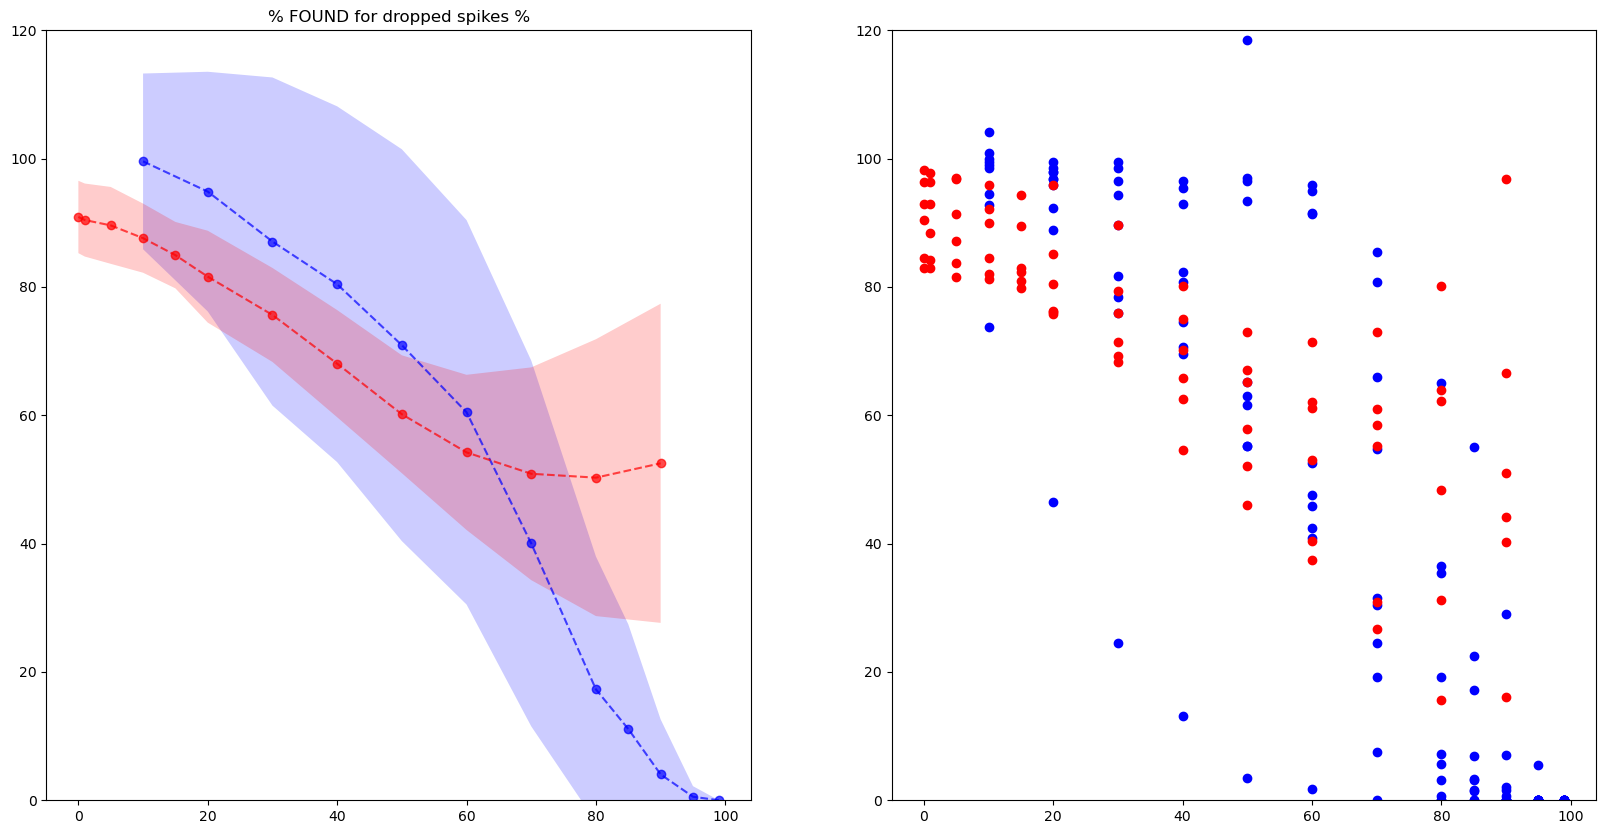

In [407]:
number = []
proportion = []
normalised_proportion = []
current_type = 'dropped_spikes'
for index,type_ in enumerate(df.type):
    if current_type in type_:
        if not np.isnan(df.proportion_found[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [df.proportion_found[index]*100]
            standard_found = standard_insertion[np.where(mouse_standard_label== df.mouse_implant_recording[index])[0][0]]
            normalised_proportion += [((df.proportion_found[index]*100)/standard_found) *100]

        
normalised_proportion = list(np.array(normalised_proportion)[np.argsort(number)])
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(normalised_proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)

fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))

ax.set_title('% FOUND for dropped spikes %')
ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'blue', alpha = 0.7)
ax.set_ylim(0,120)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'blue')


#### decoder

number = []
proportion = []
normalised_proportion = []
current_type = 'dropped_spikes'
for index,type_ in enumerate(decoder_df.type):
    if current_type in type_:
        if not np.isnan(decoder_df.proportion_found[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [decoder_df.proportion_found[index]*100]
            standard_found = standard_insertion[np.where(decoder_mouse_standard_label== decoder_df.mouse_implant_recording[index])[0][0]]
            normalised_proportion += [((decoder_df.proportion_found[index]*100)/standard_found) *100]

        
normalised_proportion = list(np.array(normalised_proportion)[np.argsort(number)])
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(normalised_proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)


ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'red', alpha = 0.7)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='red',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'red')


ax2.set_ylim(0,120)

{10: 1.042753316114579, 20: 0.9531756775148564, 30: 1.570298519859377, 40: 1.472928055581596, 50: 1.7772204915916419, 60: 2.264839693648335, 70: 4.329667263901107, 80: 22.824983796936255, 85: 18.67438650552907, 90: 32.35401703929885, 95: 25.59782608695652, 99: 19.45031712473573}
{0: 2.5013840709204915, 1: 2.556571708889587, 5: 2.42900066575563, 10: 2.3913767125687633, 15: 2.4173192823855065, 20: 2.5408476120396633, 30: 2.10118171624794, 40: 3.1618048985598635, 50: 4.141740250183957, 60: 6.754905567819473, 70: 11.933691614983003, 80: 20.346157889204243, 90: 35.93739707067522}


(0.0, 120.0)

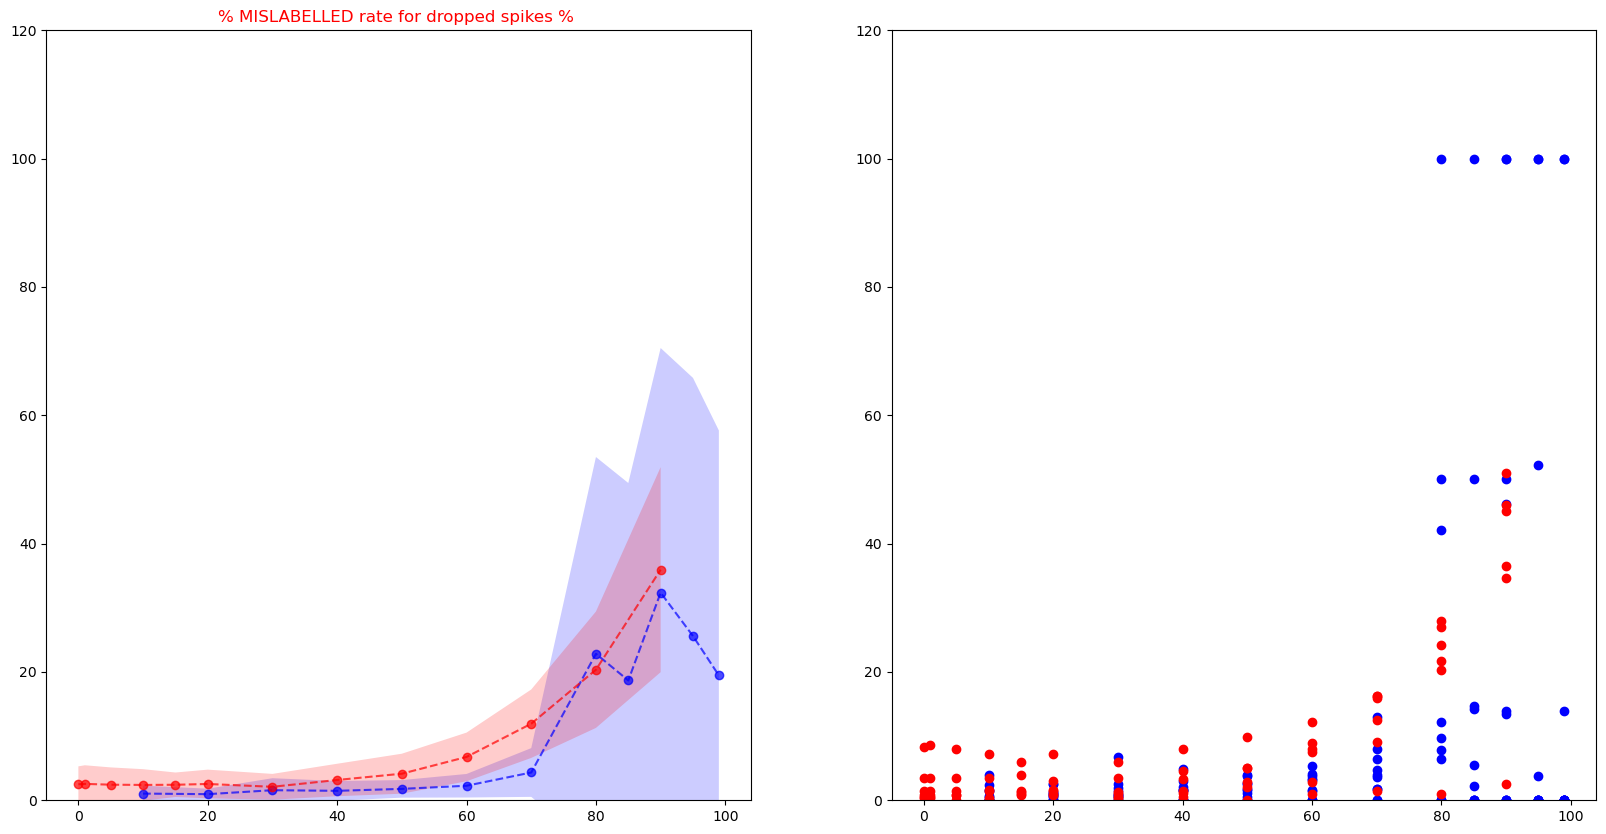

In [408]:
number = []
proportion = []
current_type = 'dropped_spikes'
for index,type_ in enumerate(df.type):
    if current_type in type_:
        if not np.isnan(df.proportion_mislabeled[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [df.proportion_mislabeled[index]*100]

proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)

fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))


ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'blue', alpha = 0.7)
ax.set_ylim(0,120)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'blue')


#### decoder

number = []
proportion = []
current_type = 'dropped_spikes'
for index,type_ in enumerate(decoder_df.type):
    if current_type in type_:
        if not np.isnan(decoder_df.proportion_mislabeled[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [decoder_df.proportion_mislabeled[index]*100]

proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)

ax.set_title('% MISLABELLED rate for dropped spikes % ', color = 'red')
ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'red', alpha = 0.7)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='red',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'red')


ax2.set_ylim(0,120)

In [438]:
pd.DataFrame({'mir':mir,'number':number,'norm_prop_true_found':normalised_proportion,'prop'})

'270_1_3'

In [409]:
# what proportion of error is explained by 1 motif. 

In [410]:
numbers = [1,1,1,0.1]

differences = []
for i in range(len(numbers) - 1):
    diff = abs(numbers[i+1] - numbers[i])
    differences.append(diff)

average_difference = sum(differences) / len(differences)

print("Average Difference:", average_difference)


Average Difference: 0.3


In [411]:
attempts = [
    [4, 0.9827586206896551, 1.0, 0.7068965517241379],
    # Add more attempts here...
]

num_types = len(attempts[0])  # Assuming all attempts have the same number of types
weights = [1/num_types] * num_types  # Equal weights for each type

bias_scores = []

for attempt in attempts:
    weighted_proportions = [p * w for p, w in zip(attempt, weights)]
    bias_score = sum(weighted_proportions)
    bias_scores.append(bias_score)

print(bias_scores)


[1.6724137931034482]


In [412]:
def calculate_bias_score(attempts):
    num_attempts = len(attempts)
    num_event_types = len(attempts[0])  # Assuming all attempts have the same number of event types
    
    expected_proportion = 1.0
    
    total_abs_diff = [0] * num_event_types
    
    for attempt in attempts:
        for i in range(num_event_types):
            abs_diff = abs(attempt[i] - expected_proportion)
            total_abs_diff[i] += abs_diff
    
    normalized_abs_diff = [abs_diff / num_attempts for abs_diff in total_abs_diff]
    
    average_bias_score = sum(normalized_abs_diff) / num_event_types
    
    return average_bias_score

# the code calculates the average bias score for a given list of attempts. It compares the reported proportions of each event type in each attempt with the expected proportion of 1.0. It calculates the absolute differences, sums them up for each event type across all attempts, normalizes them by dividing by the number of possible outcomes, and then calculates the average to obtain a single bias score that represents the overall bias of the scorer.


In [413]:
def calculate_msd(attempts):
    num_attempts = len(attempts)
    num_event_types = len(attempts[0])  # Assuming all attempts have the same number of event types
    
    expected_proportion = 1.0
    
    total_signed_deviation = [0] * num_event_types
    
    for attempt in attempts:
        for i in range(num_event_types):
            signed_deviation = attempt[i] - expected_proportion
            total_signed_deviation[i] += signed_deviation
    
    average_signed_deviation = [deviation / num_attempts for deviation in total_signed_deviation]
    
    return average_signed_deviation


In [414]:
calculate_msd([[4, 0.9827586206896551, 1.0, 0.7068965517241379]])

[3.0, -0.017241379310344862, 0.0, -0.2931034482758621]

In [508]:
mouse_standard_label

array(['136_1_3', '148_2_2', '149_1_1', '178_1_6', '178_1_7', '178_2_1',
       '178_2_3', '178_2_4', '269_1_2', '270_1_3'], dtype=object)

{10: 72.44676732782487, 20: 66.2474149589981, 30: 76.6295223967991, 40: 65.95297443488751, 50: 58.38350725093265, 60: 57.88779410835383, 70: 59.878812734917815, 80: 55.00145465542448}
{10: 5.646767327824881, 20: 9.520142231725375, 30: 6.2295223967991005, 40: 3.4529744348875027, 50: 8.68350725093266, 60: 14.037794108353827, 70: 16.32881273491782, 80: 15.188954655424476}
{10: 80.03039262062441, 20: 54.24792476237389, 30: 80.90609763672678, 40: 91.53114828512179, 50: 100.0, 60: 100.0}
{10: 5.364466806188657, 20: 8.641540110835713, 30: 28.262879265693833, 40: 44.26151271465841, 50: 64.87103174603175, 60: 66.15936147186147}


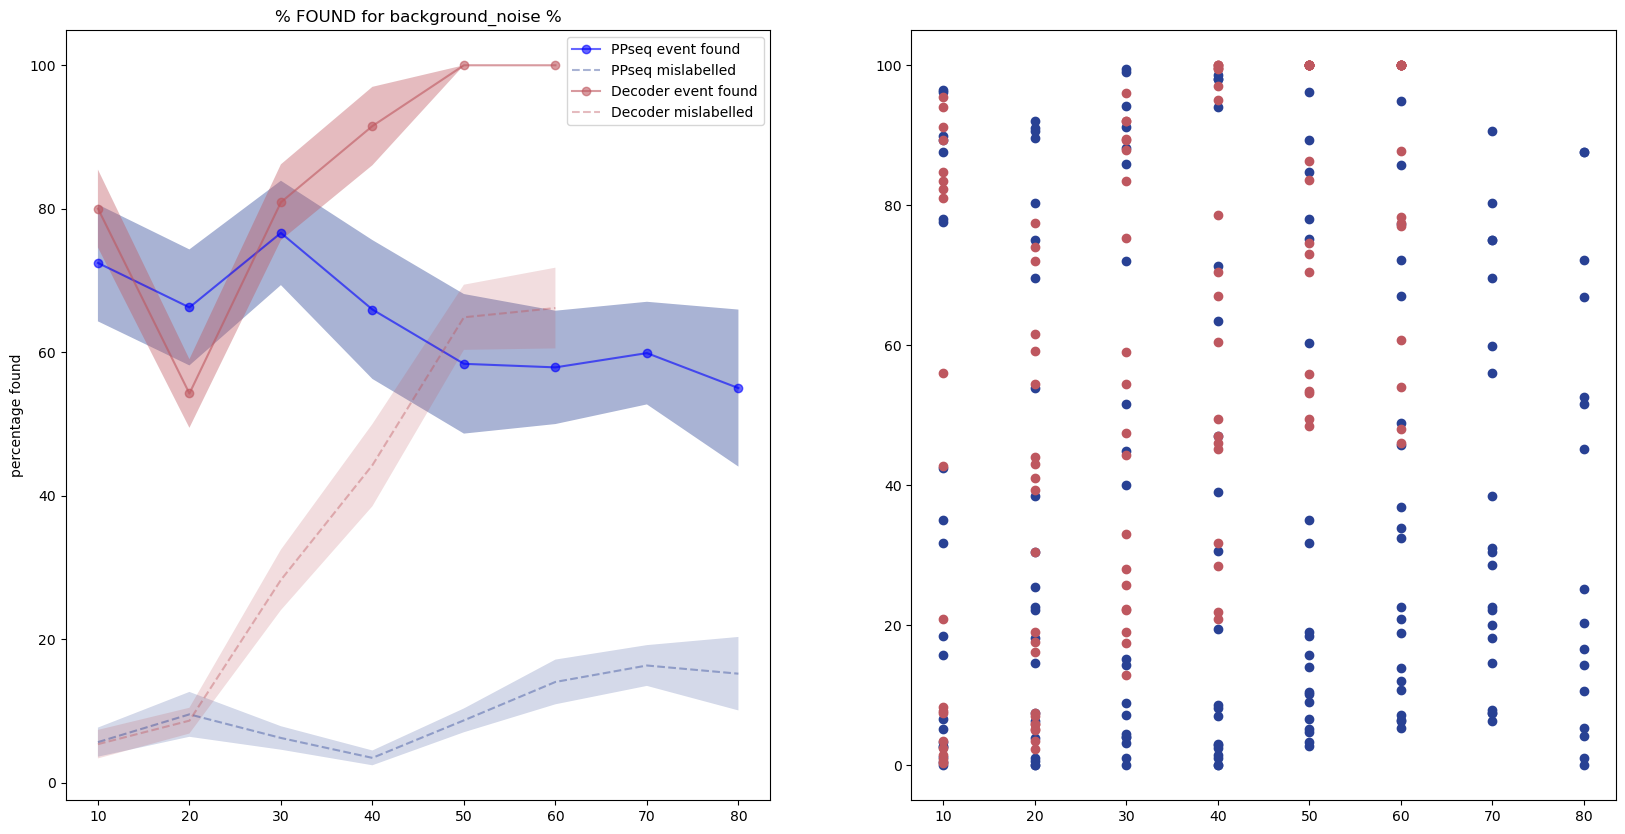

{20: 77.5079507484272, 40: 60.290690541145, 80: 84.5273625437476, 100: 78.18186908434546, 200: 58.0510097838535, 300: 48.87434938432391, 400: 44.763673752323434, 500: 44.64261515324327}
{0: 90.90655053070557, 20: 53.884643651235386, 40: 50.1357898700271, 80: 56.099802749610895, 100: 57.075720986718345, 200: 47.51311955386541, 300: 42.0813610652699, 400: 40.068371361603404, 500: 37.511976314048134}


(0.0, 120.0)

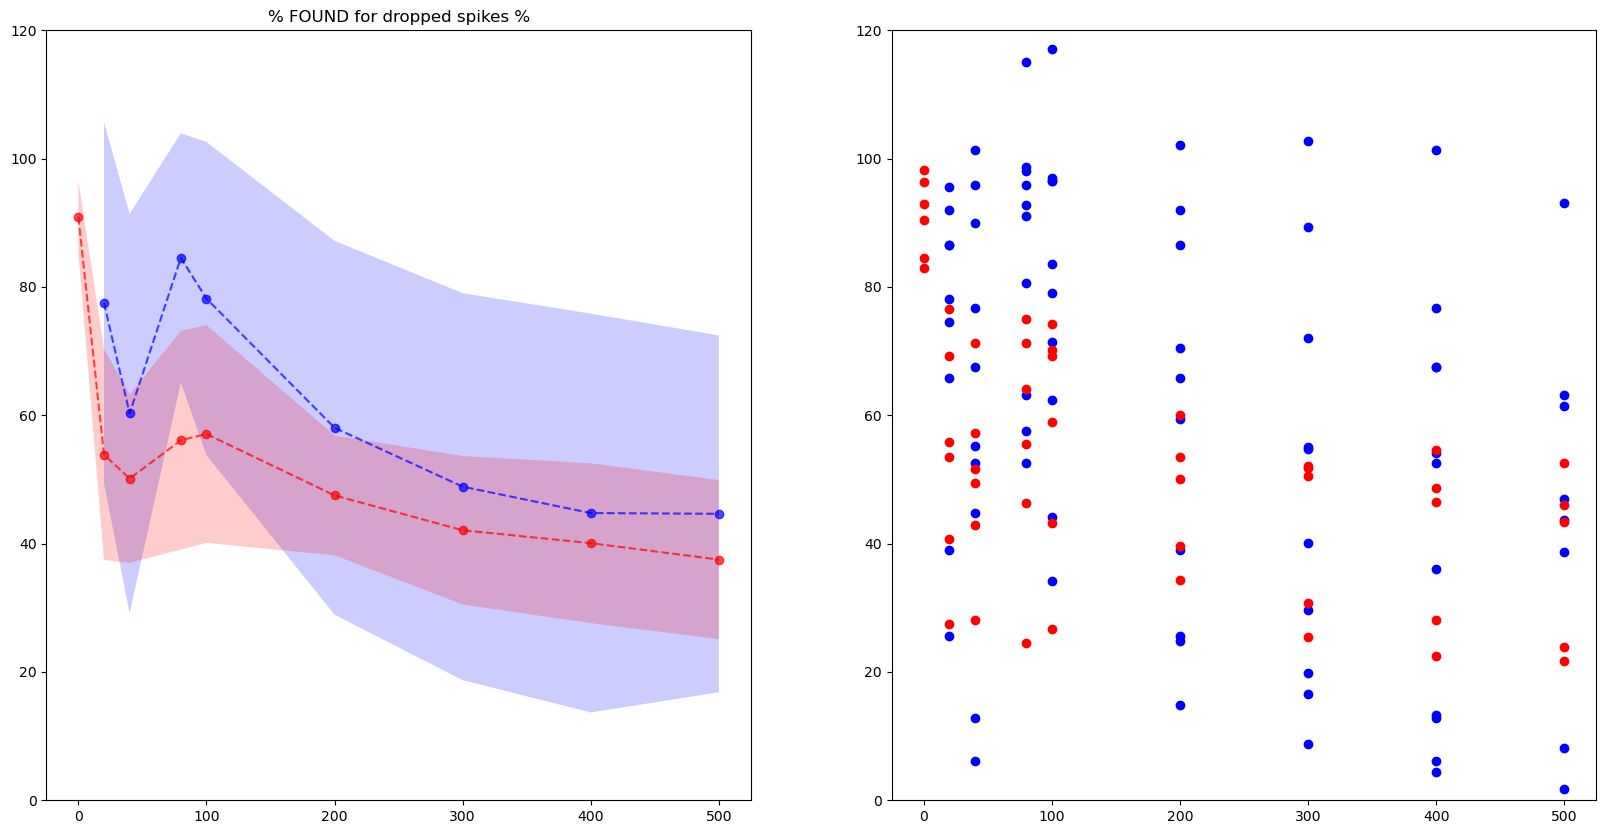

In [415]:
number = []
proportion = []
normalised_proportion = []
current_type = 'background_noise'
for index,type_ in enumerate(df.type):
    if current_type in type_:
        if not np.isnan(df.proportion_found[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [df.proportion_found[index]*100]
            standard_found = standard_insertion[np.where(mouse_standard_label== df.mouse_implant_recording[index])[0][0]]
            normalised_proportion += [((df.proportion_found[index]*100)/standard_found) *100]

        
normalised_proportion = list(np.array(normalised_proportion)[np.argsort(number)])
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(normalised_proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)

fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))

ax.set_title('% FOUND for background noise insertion')
ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'blue', alpha = 0.7)
ax.set_ylim(0,120)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'blue')


#### decoder

number = []
proportion = []
normalised_proportion = []
current_type = 'background_noise'
for index,type_ in enumerate(decoder_df.type):
    if current_type in type_:
        if not np.isnan(decoder_df.proportion_found[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [decoder_df.proportion_found[index]*100]
            standard_found = standard_insertion[np.where(decoder_mouse_standard_label== decoder_df.mouse_implant_recording[index])[0][0]]
            normalised_proportion += [((decoder_df.proportion_found[index]*100)/standard_found) *100]

        
normalised_proportion = list(np.array(normalised_proportion)[np.argsort(number)])
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(normalised_proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)


ax.set_title('% FOUND for dropped spikes %')
ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'red', alpha = 0.7)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='red',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'red')


ax2.set_ylim(0,120)

{20: 5.646767327824881, 40: 10.416290534897914, 80: 4.848262568296107, 100: 4.073773652778253, 200: 8.590742871544903, 300: 11.26267449203804, 400: 18.19365751021237, 500: 15.188954655424476}
{0: 2.5013840709204915, 20: 6.323241879533269, 40: 10.201399838817055, 80: 24.510402431760046, 100: 30.74688146045762, 200: 53.83095238095238, 300: 59.2515873015873, 400: 61.19047619047619, 500: 63.60952380952381}


(0.0, 120.0)

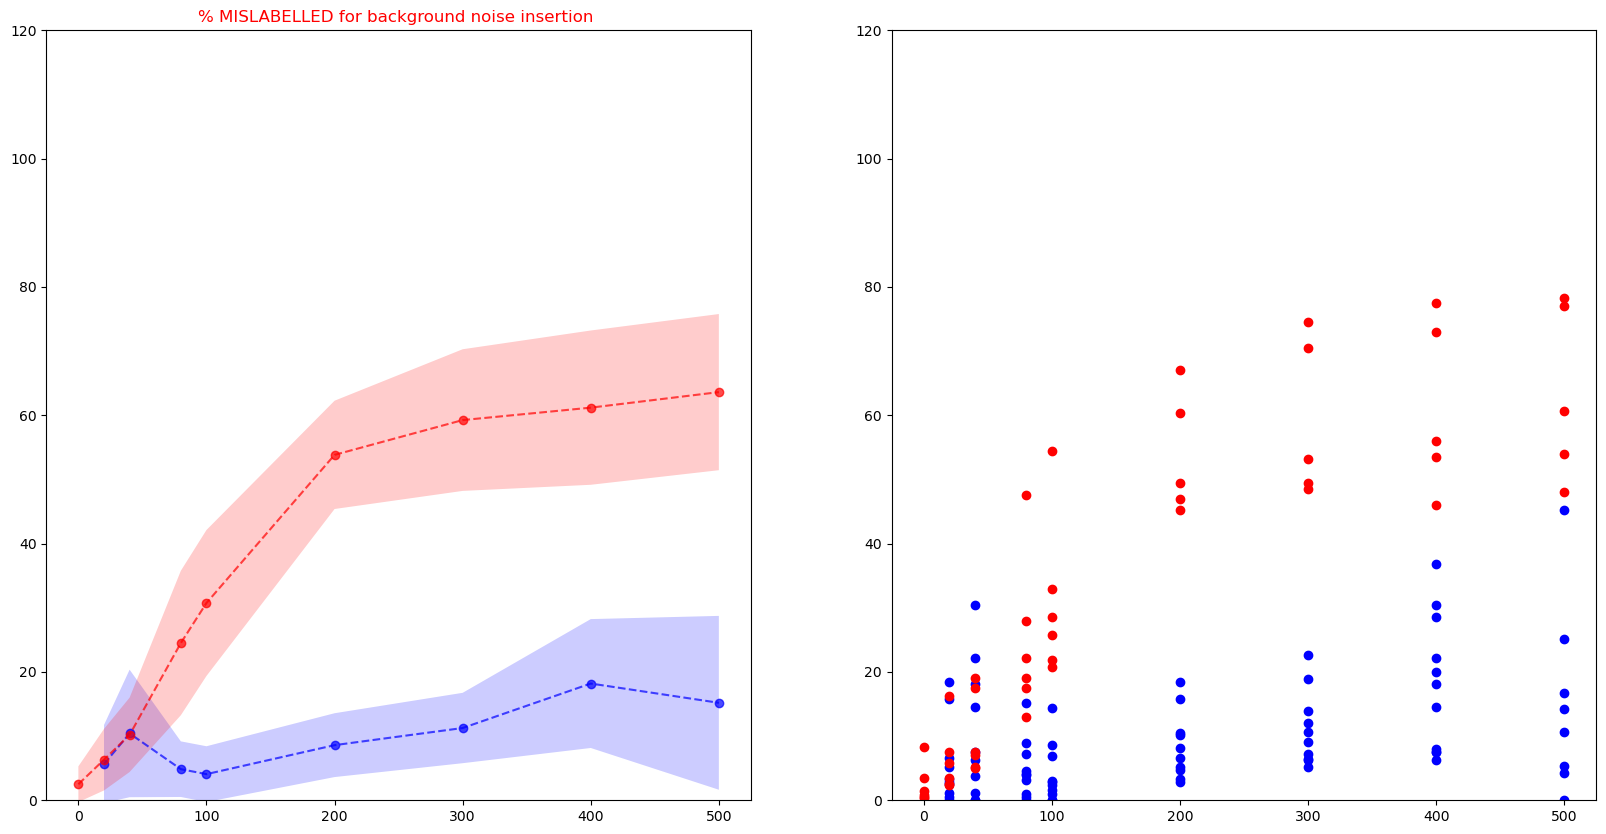

In [416]:
number = []
proportion = []

current_type = 'background_noise'
for index,type_ in enumerate(df.type):
    if current_type in type_:
        if not np.isnan(df.proportion_mislabeled[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [df.proportion_mislabeled[index]*100]

proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)

fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))

ax.set_title('% FOUND for background noise insertion')
ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'blue', alpha = 0.7)
ax.set_ylim(0,120)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'blue')


#### decoder

number = []
proportion = []

current_type = 'background_noise'
for index,type_ in enumerate(decoder_df.type):
    if current_type in type_:
        if not np.isnan(decoder_df.proportion_mislabeled[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [decoder_df.proportion_mislabeled[index]*100]



proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)

ax.set_title('% MISLABELLED for background noise insertion ', color = 'red')

ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'red', alpha = 0.7)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='red',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'red')


ax2.set_ylim(0,120)

# misordered insertion 

{10: 76.9481174866427, 20: 100.65280624927988, 30: 94.81098137801916, 40: 90.51768462386596, 50: 84.21472321397783, 60: 74.41140359366891, 70: 64.0725927296784, 80: 63.68101729084855, 90: 56.020908941786146, 100: 45.629777896080306}
{0: 90.90655053070557, 10: 85.9241614211726, 20: 83.02684566995468, 30: 80.00459159196605, 40: 74.3532282028255, 50: 71.84831408185269, 60: 70.29123036510138, 70: 70.58650282881467, 80: 70.67148972174516, 90: 70.46798507849604, 100: 69.19282620620272}


(0.0, 120.0)

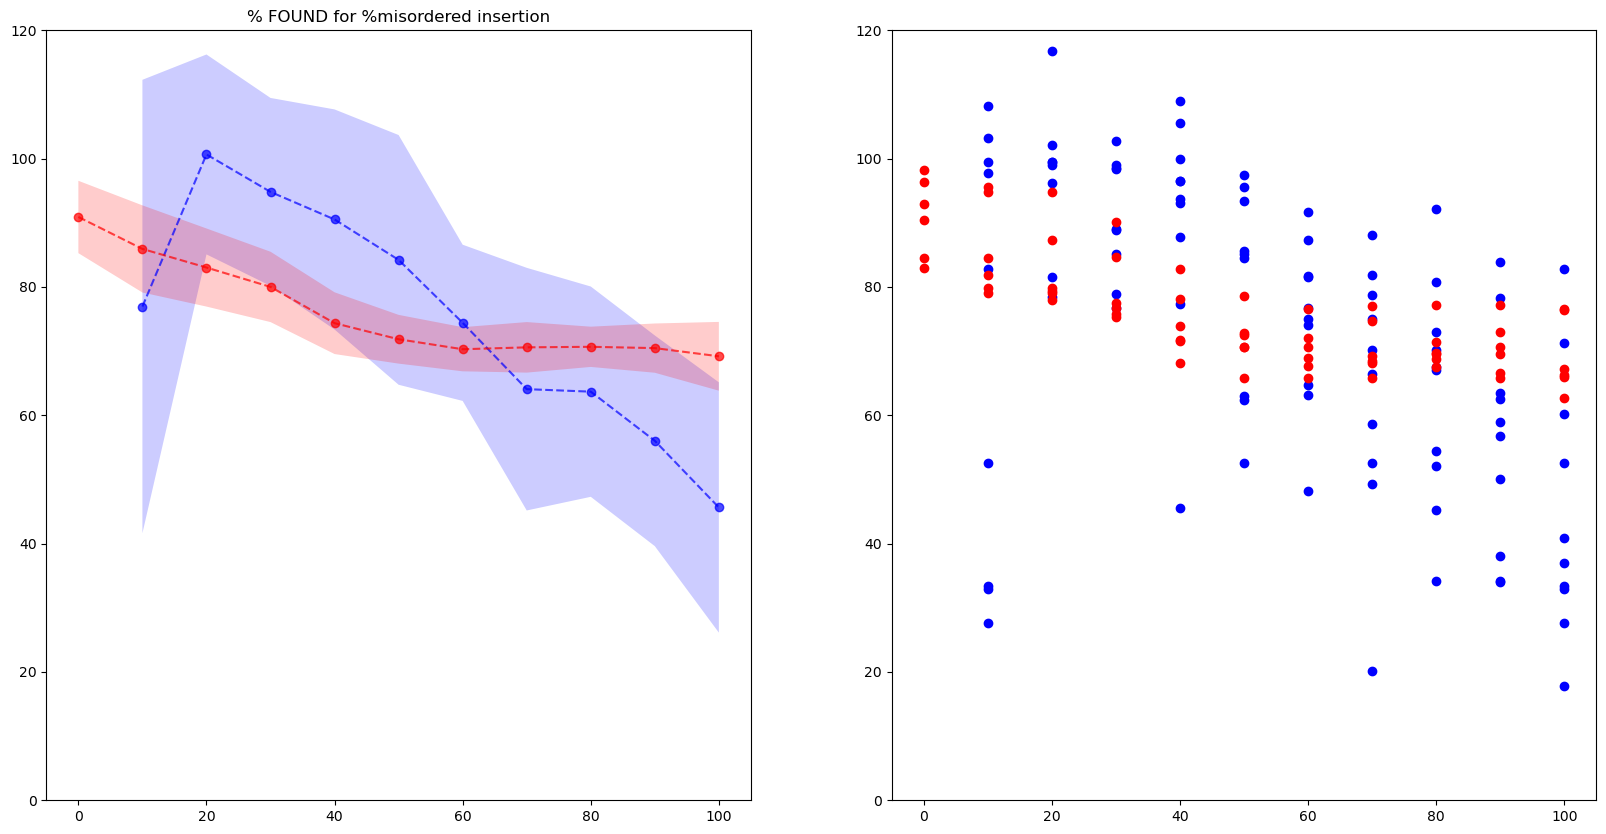

In [417]:
number = []
proportion = []
normalised_proportion = []
current_type = 'swapped_spikes'
for index,type_ in enumerate(df.type):
    if current_type in type_:
        if not np.isnan(df.proportion_found[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [df.proportion_found[index]*100]
            standard_found = standard_insertion[np.where(mouse_standard_label== df.mouse_implant_recording[index])[0][0]]
            normalised_proportion += [((df.proportion_found[index]*100)/standard_found) *100]

        
normalised_proportion = list(np.array(normalised_proportion)[np.argsort(number)])
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(normalised_proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)

fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))

ax.set_title('% FOUND for background noise insertion')
ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'blue', alpha = 0.7)
ax.set_ylim(0,120)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'blue')


#### decoder

number = []
proportion = []
normalised_proportion = []
current_type = 'swapped_spikes'
for index,type_ in enumerate(decoder_df.type):
    if current_type in type_:
        if not np.isnan(decoder_df.proportion_found[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [decoder_df.proportion_found[index]*100]
            standard_found = standard_insertion[np.where(decoder_mouse_standard_label== decoder_df.mouse_implant_recording[index])[0][0]]
            normalised_proportion += [((decoder_df.proportion_found[index]*100)/standard_found) *100]

        
normalised_proportion = list(np.array(normalised_proportion)[np.argsort(number)])
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(normalised_proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)


ax.set_title('% FOUND for %misordered insertion')
ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'red', alpha = 0.7)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='red',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'red')


ax2.set_ylim(0,120)

{10: 2.476359787801918, 20: 1.0174502345450722, 30: 1.9508556396111971, 40: 1.254130655940793, 50: 1.444016850852095, 60: 1.865658358988984, 70: 2.275154658710773, 80: 3.21485990260493, 90: 1.503857220633264, 100: 3.327274335969986}
{0: 2.5013840709204915, 10: 2.723606293142713, 20: 2.7206673324222965, 30: 2.868666561547355, 40: 3.2915790672413165, 50: 3.854037457514277, 60: 3.9998335610918367, 70: 4.65738550755107, 80: 5.571406671572233, 90: 6.143347699639087, 100: 6.653925330249832}


(0.0, 100.0)

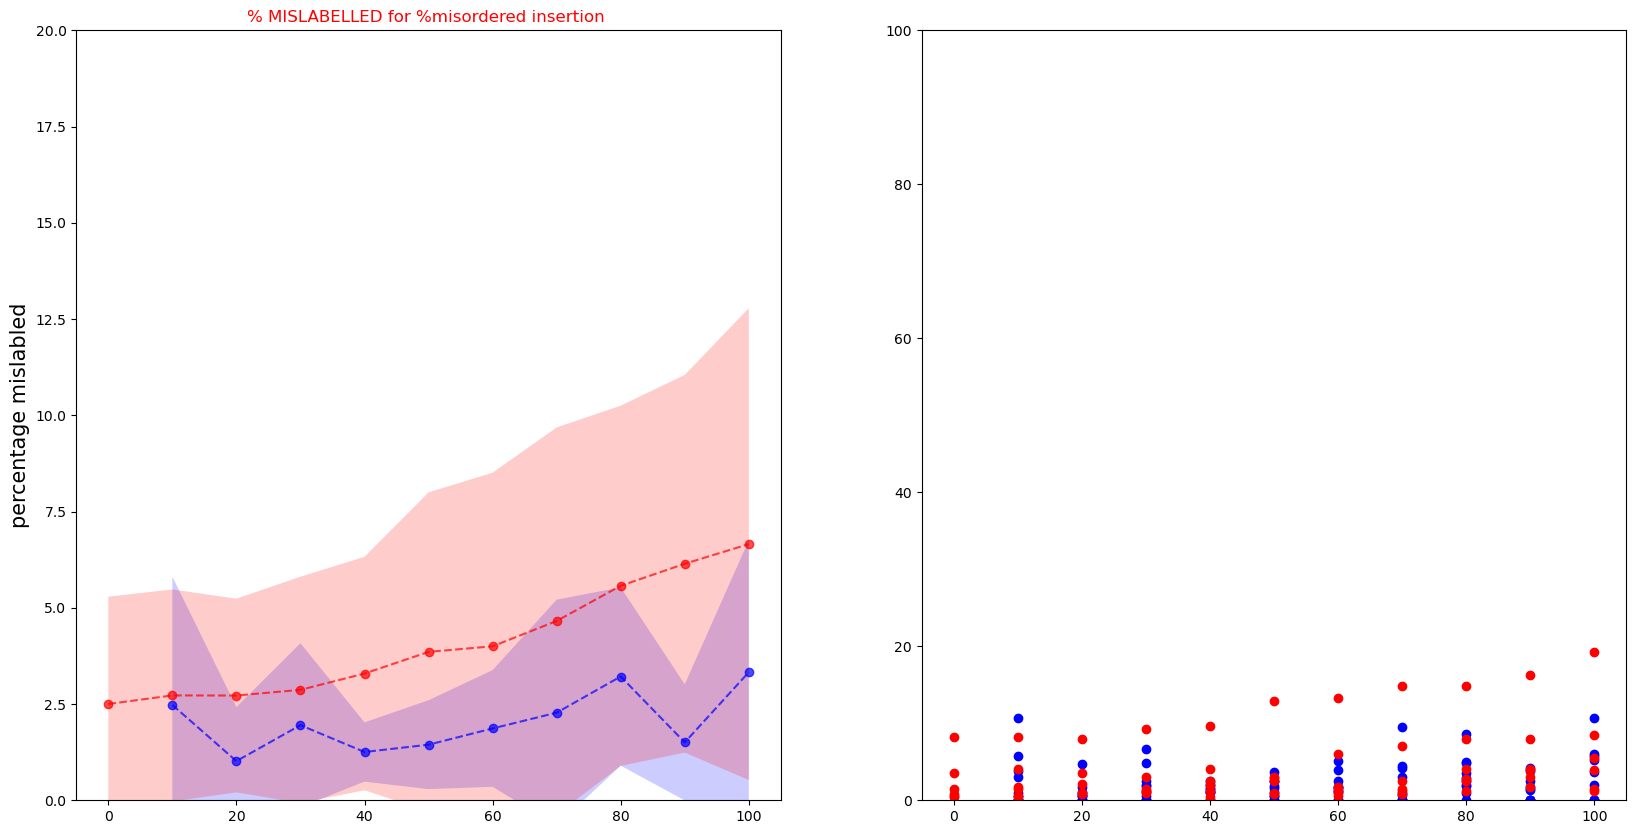

In [428]:
number = []
proportion = []

current_type = 'swapped_spikes'
for index,type_ in enumerate(df.type):
    if current_type in type_:
        if not np.isnan(df.proportion_mislabeled[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [df.proportion_mislabeled[index]*100]
            
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)

fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))

ax.set_title('% FOUND for background noise insertion')
ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'blue', alpha = 0.7)
ax.set_ylim(0,20)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'blue')


#### decoder

number = []
proportion = []

current_type = 'swapped_spikes'
for index,type_ in enumerate(decoder_df.type):
    if current_type in type_:
        if not np.isnan(decoder_df.proportion_mislabeled[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [decoder_df.proportion_mislabeled[index]*100]

proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)

ax.set_title('% MISLABELLED for %misordered insertion ', color = 'red')

ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'red', alpha = 0.7)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='red',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'red')

ax.set_ylabel('percentage mislabled',size = 15)
ax2.set_ylim(0,100)

# WARP insertion

136_1_3
148_2_2
149_1_1
178_1_6
178_1_7
178_2_1
178_2_3
178_2_4
178_2_4
269_1_2
270_1_3
{0.03: 62.293929888344785, 0.1: 52.63874552323446, 0.2: 84.6316505830652, 0.5: 81.06292107170322, 1.0: 100.0, 2.0: 31.335421964623574, 5.0: 76.89254530658359, 10.0: 39.00438418578685, 20.0: 5.241137200736649, 30.0: 0.8}
136_1_3
178_1_6
178_1_7
178_2_1
178_2_3
178_2_4
{0.03: 97.6690772240302, 0.1: 90.49947363497229, 0.2: 89.46772985569767, 0.5: 90.2873014896945, 1.0: 98.12915016057191, 2.0: 81.04182299830101, 5.0: 63.491281388806314, 10.0: 58.153993003431054, 20.0: 54.994550073068496, 30.0: 48.55106795903738}


(0.0, 110.0)

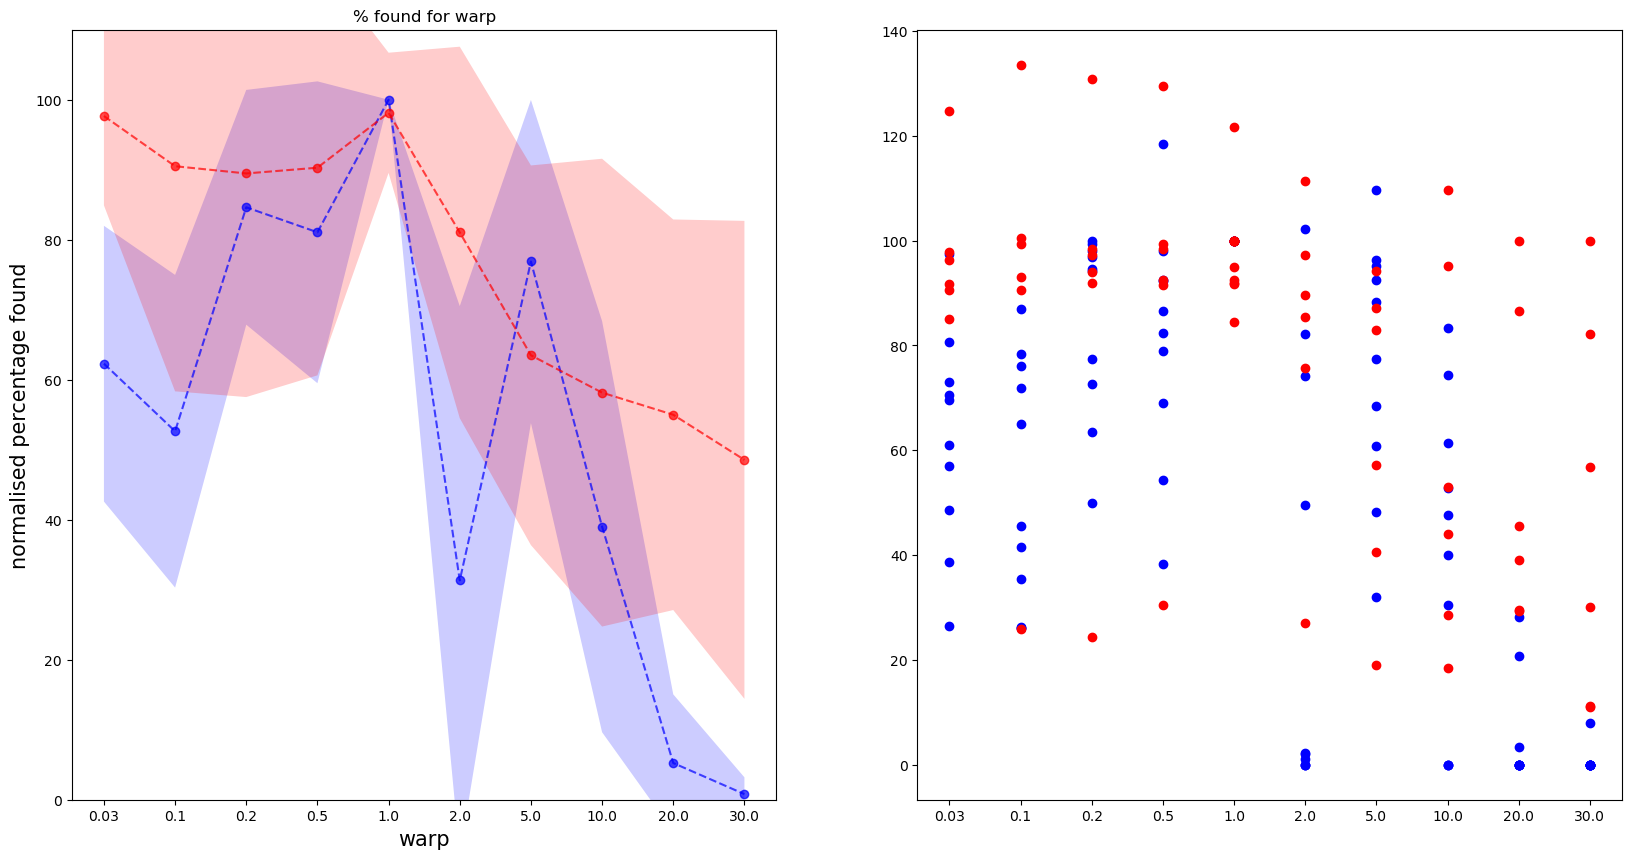

In [419]:
number = []
proportion = []
normalised_proportion = []
current_type = 'warp'
for index,type_ in enumerate(df.type):
    if current_type in type_:
        proportion += [df.proportion_found[index]*100]
        standard_found = standard_insertion[np.where(mouse_standard_label== df.mouse_implant_recording[index])[0][0]]
        normalised_proportion += [((df.proportion_found[index]*100)/standard_found) *100]
        try:
            number += [float(re.findall(r'\d+\.\d+', type_)[0])]
            if float(re.findall(r'\d+\.\d+', type_)[0]) == 0.1:
                print(df.mouse_implant_recording[index])
        except:
            number += [int(re.findall(r'\d+', type_)[0])]

            
number += [1]*len(np.where(number == np.unique(number)[0])[0])
proportion += [100]*len(np.where(number == np.unique(number)[0])[0])
normalised_proportion += [100]*len(np.where(number == np.unique(number)[0])[0])
             

normalised_proportion = list(np.array(normalised_proportion)[np.argsort(number)])
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(normalised_proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)

fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))

labels = list(np.sort(np.unique(number)).astype(str))
ax.set_xticks(range(0,len(labels)))
ax.set_xticklabels(labels)

x_val = np.sort(list(range(0,len(np.unique(labels)))) * len(np.where(number == np.unique(number)[0])[0]))
# ax.plot(x_val,normalised_proportion, 'o', color = 'grey')
ax.plot(np.sort(list(range(0,len(np.unique(labels))))),group_means.values(), 'o--', color = 'blue', alpha = 0.7)


group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(np.sort(list(range(0,len(np.unique(labels))))),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [np.sort(list(range(0,len(np.unique(labels)))))[i]]*len(y)
    ax2.plot(x_,y,'o',color = 'blue')



ax.set_title('% found for warp')


ax.set_ylabel('normalised percentage found',size = 15)
ax.set_xlabel('warp',size = 15)

ax.set_ylim(0,110)


#### decoder


number = []
proportion = []
normalised_proportion = []
current_type = 'warp'
for index,type_ in enumerate(decoder_df.type):
    if current_type in type_:
        proportion += [decoder_df.proportion_found[index]*100]
        standard_found = standard_insertion[np.where(mouse_standard_label== decoder_df.mouse_implant_recording[index])[0][0]]
        normalised_proportion += [((decoder_df.proportion_found[index]*100)/standard_found) *100]
        try:
            number += [float(re.findall(r'\d+\.\d+', type_)[0])]
            if float(re.findall(r'\d+\.\d+', type_)[0]) == 0.1:
                print(decoder_df.mouse_implant_recording[index])
        except:
            number += [int(re.findall(r'\d+', type_)[0])]

            
number += [1]*len(np.where(number == np.unique(number)[0])[0])
proportion += [100]*len(np.where(number == np.unique(number)[0])[0])
normalised_proportion += [100]*len(np.where(number == np.unique(number)[0])[0])
             

normalised_proportion = list(np.array(normalised_proportion)[np.argsort(number)])
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(normalised_proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)


labels = list(np.sort(np.unique(number)).astype(str))
ax.set_xticks(range(0,len(labels)))
ax.set_xticklabels(labels)

ax2.set_xticks(range(0,len(labels)))
ax2.set_xticklabels(labels)


x_val = np.sort(list(range(0,len(np.unique(labels)))) * len(np.where(number == np.unique(number)[0])[0]))
# ax.plot(x_val,normalised_proportion, 'o', color = 'grey')
ax.plot(np.sort(list(range(0,len(np.unique(labels))))),group_means.values(), 'o--', color = 'red', alpha = 0.7)


group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(np.sort(list(range(0,len(np.unique(labels))))),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='red',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [np.sort(list(range(0,len(np.unique(labels)))))[i]]*len(y)
    ax2.plot(x_,y,'o',color = 'red')



ax.set_title('% found for warp')


ax.set_ylabel('normalised percentage found',size = 15)
ax.set_xlabel('warp',size = 15)

ax.set_ylim(0,110)

136_1_3
148_2_2
149_1_1
178_1_6
178_1_7
178_2_1
178_2_3
178_2_4
178_2_4
269_1_2
270_1_3
{0.03: 6.159633972837805, 0.1: 17.574054609763287, 0.2: 4.803355334279672, 0.5: 5.5862641396508375, 1.0: 1.290531362609936, 2.0: 23.17882269723357, 5.0: 2.6681887045805253, 10.0: 2.559523809523809, 20.0: 0.0, 30.0: 0.051282051282051}
136_1_3
178_1_6
178_1_7
178_2_1
178_2_3
178_2_4
{0.03: 10.333333333333334, 0.1: 9.916666666666666, 0.2: 8.083333333333334, 0.5: 5.833333333333333, 1.0: 4.109729429265851, 2.0: 7.3785746390763585, 5.0: 31.94985168705969, 10.0: 39.22832722832723, 20.0: 44.40423976608187, 30.0: 48.26599326599327}


(0.0, 110.0)

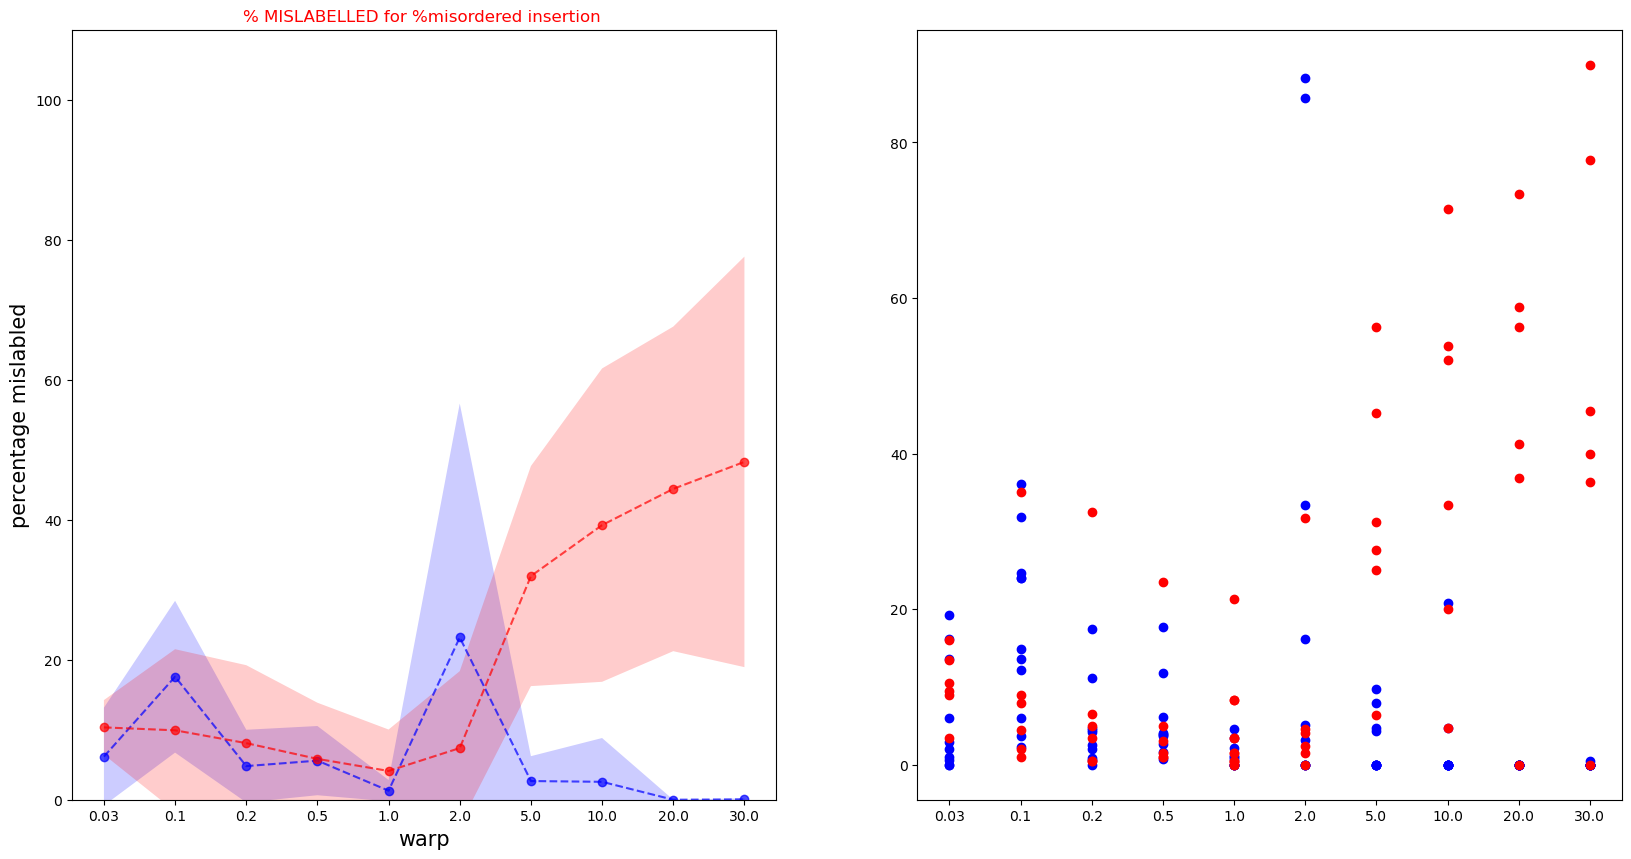

In [427]:
number = []
proportion = []
current_type = 'warp'
for index,type_ in enumerate(df.type):
    if current_type in type_:
        proportion += [df.proportion_mislabeled[index]*100]
        standard_found = standard_insertion[np.where(mouse_standard_label== df.mouse_implant_recording[index])[0][0]]
        try:
            number += [float(re.findall(r'\d+\.\d+', type_)[0])]
            if float(re.findall(r'\d+\.\d+', type_)[0]) == 0.1:
                print(df.mouse_implant_recording[index])
        except:
            number += [int(re.findall(r'\d+', type_)[0])]

            
number += [1]*len(np.where(number == np.unique(number)[0])[0])
proportion += list(standard_insertion_mislabeled)
             
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)

fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))

labels = list(np.sort(np.unique(number)).astype(str))
ax.set_xticks(range(0,len(labels)))
ax.set_xticklabels(labels)

x_val = np.sort(list(range(0,len(np.unique(labels)))) * len(np.where(number == np.unique(number)[0])[0]))

ax.plot(np.sort(list(range(0,len(np.unique(labels))))),group_means.values(), 'o--', color = 'blue', alpha = 0.7)


group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(np.sort(list(range(0,len(np.unique(labels))))),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [np.sort(list(range(0,len(np.unique(labels)))))[i]]*len(y)
    ax2.plot(x_,y,'o',color = 'blue')



ax.set_title('% found for warp')


ax.set_ylabel('normalised percentage found',size = 15)
ax.set_xlabel('warp',size = 15)

ax.set_ylim(0,110)

#### decoder


number = []
proportion = []

current_type = 'warp'
for index,type_ in enumerate(decoder_df.type):
    if current_type in type_:
        proportion += [decoder_df.proportion_mislabeled[index]*100]
        standard_found = standard_insertion[np.where(mouse_standard_label== decoder_df.mouse_implant_recording[index])[0][0]]
        try:
            number += [float(re.findall(r'\d+\.\d+', type_)[0])]
            if float(re.findall(r'\d+\.\d+', type_)[0]) == 0.1:
                print(decoder_df.mouse_implant_recording[index])
        except:
            number += [int(re.findall(r'\d+', type_)[0])]

            
number += [1]*len(np.where(number == np.unique(number)[0])[0])
proportion += decoder_standard_insertion_mislabeled
             
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    

group_values = {}
for value, group in zip(proportion, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)


labels = list(np.sort(np.unique(number)).astype(str))
ax.set_xticks(range(0,len(labels)))
ax.set_xticklabels(labels)

ax2.set_xticks(range(0,len(labels)))
ax2.set_xticklabels(labels)


x_val = np.sort(list(range(0,len(np.unique(labels)))) * len(np.where(number == np.unique(number)[0])[0]))
# ax.plot(x_val,normalised_proportion, 'o', color = 'grey')
ax.plot(np.sort(list(range(0,len(np.unique(labels))))),group_means.values(), 'o--', color = 'red', alpha = 0.7)


group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(np.sort(list(range(0,len(np.unique(labels))))),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='red',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [np.sort(list(range(0,len(np.unique(labels)))))[i]]*len(y)
    ax2.plot(x_,y,'o',color = 'red')



ax.set_title('% MISLABELLED for %misordered insertion ', color = 'red')


ax.set_ylabel('percentage mislabled',size = 15)
ax.set_xlabel('warp',size = 15)

ax.set_ylim(0,110)

#  BIAS scores  ----------------------------------------

In [421]:
# Bias is calculated as the normalised mean deviation from expected proportions of motifs:

# if 25% were found we expect 25% from all seqs if no bias
# but we actually have [10,20,20,110]
# so here the biases are (15,20,20,85)
# so overall bias is (140/4)/25 



# dropped_spikes

{0: 3.957179037959174, 1: 6.1966256344082336, 5: 1.8617058757925873, 10: 2.4234030726937514, 15: 3.414717478795168, 20: 2.956581327021942, 30: 4.79408047606697, 40: 1.0895496036433314, 50: 0.8949611536210722, 60: 2.757310088152104, 70: 1.4129919981018029, 80: 1.4376640597830794, 90: 0.8342679455762805}


C:\Users\Emmett\AppData\Local\Temp\ipykernel_7840\312691150.py:22: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])
C:\Users\Emmett\AppData\Local\Temp\ipykernel_7840\312691150.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])


Text(0, 0.5, 'Bias score')

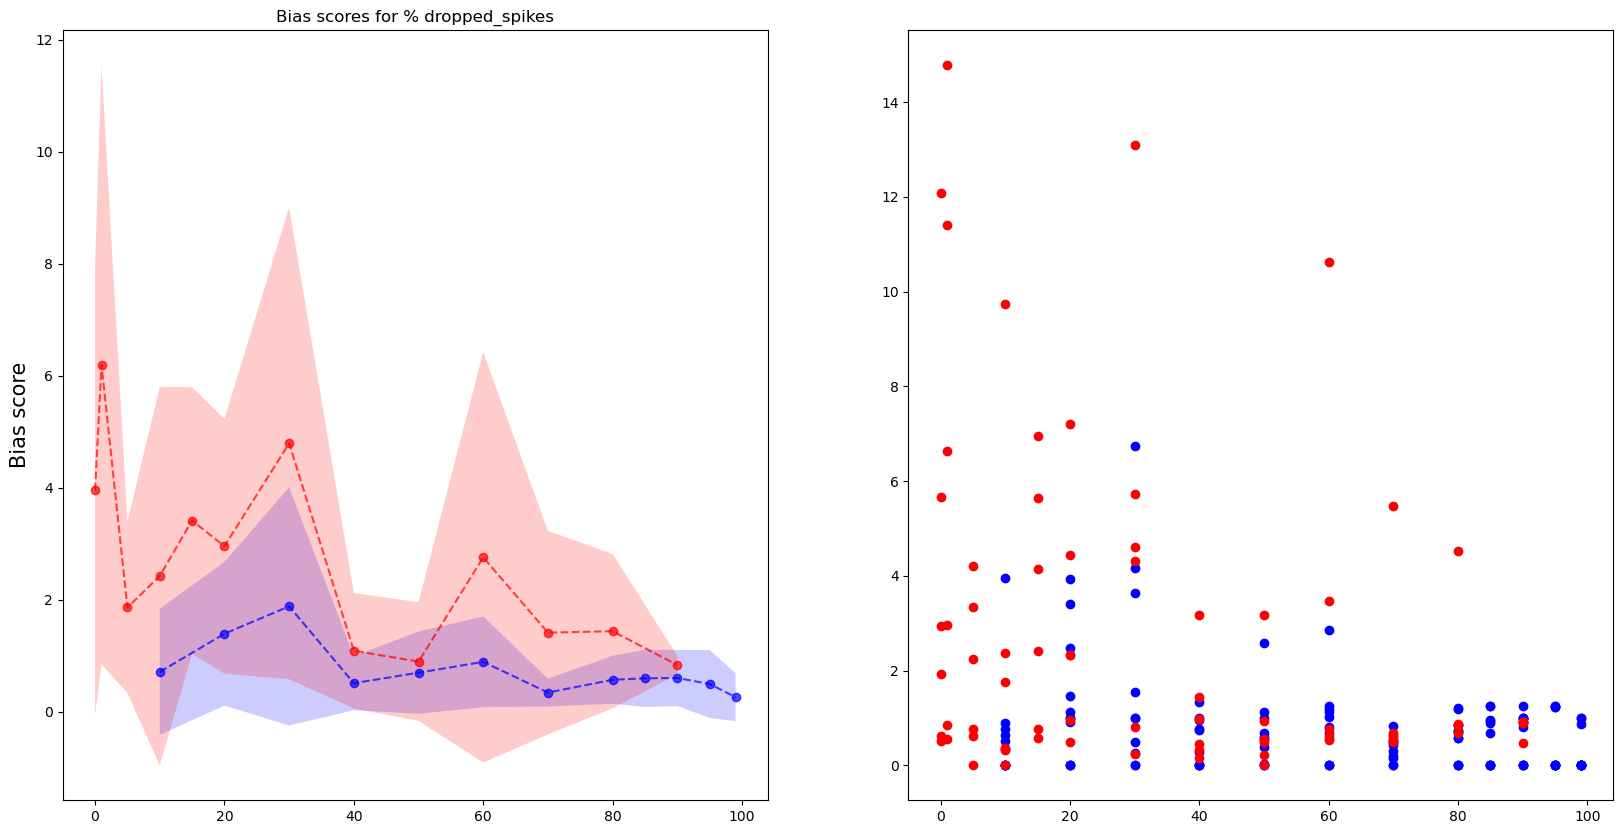

In [422]:
### calculate the largest deviance from expected. 
#How much of total proportion found is attributed to one motif. 
## how muhc of total p[roportion not found is because of one motif



import ast
number = []
prop_seqs_found_individual = []
proportion =[]

current_type = 'dropped_spikes'
for index,type_ in enumerate(df.type):
    if current_type in type_:
        if not np.isnan(df.proportion_found[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [df.proportion_mislabeled[index]*100]
            prop_seqs_found_individual += [ast.literal_eval(df.seqs_found_over_implanted[index])]
            
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    
prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])
        
normalised_bias_score = []
for index,prop in enumerate(proportion):
    if prop > 0:
        prop_seqs = prop_seqs_found_individual[index]
        expected_prop = prop/len(prop_seqs) # expected if all seqs were equal given outcome prop found
        normalised_bias_score  += [((sum(abs(np.array(prop_seqs) - expected_prop))/4) / expected_prop)]
    else:
        normalised_bias_score += [0]
        
group_values = {}
for value, group in zip(normalised_bias_score, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)


fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))


ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'blue', alpha = 0.7)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'blue')
    
    
### decoder

import ast
number = []
prop_seqs_found_individual = []
proportion =[]

current_type = 'dropped_spikes'
for index,type_ in enumerate(decoder_df.type):
    if current_type in type_:
        if not np.isnan(decoder_df.proportion_found[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [decoder_df.proportion_mislabeled[index]*100]
            prop_seqs_found_individual += [ast.literal_eval(decoder_df.seqs_found_over_implanted[index])]
            
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    
prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])
        
normalised_bias_score = []
for index,prop in enumerate(proportion):
    if prop > 0:
        prop_seqs = prop_seqs_found_individual[index]
        expected_prop = prop/len(prop_seqs) # expected if all seqs were equal given outcome prop found
        normalised_bias_score  += [((sum(abs(np.array(prop_seqs) - expected_prop))/4) / expected_prop)]
    else:
        normalised_bias_score += [0]
        
group_values = {}
for value, group in zip(normalised_bias_score, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)


ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'red', alpha = 0.7)


group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='red',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'red')
    
    
ax.set_title('Bias scores for % dropped_spikes')
ax.set_ylabel('Bias score', size = 15)


# misordered

{0: 6.491587850014257, 10: 5.321458758998902, 20: 1.8991733913645399, 30: 2.3446793202628755, 40: 4.087578155463364, 50: 1.9211753521009056, 60: 1.3345961535536102, 70: 4.437700341699172, 80: 3.0470647653529617, 90: 0.9311322139888536, 100: 0.8786536419424847}


C:\Users\Emmett\AppData\Local\Temp\ipykernel_7840\3786335135.py:22: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])
C:\Users\Emmett\AppData\Local\Temp\ipykernel_7840\3786335135.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])


Text(0, 0.5, 'Bias score')

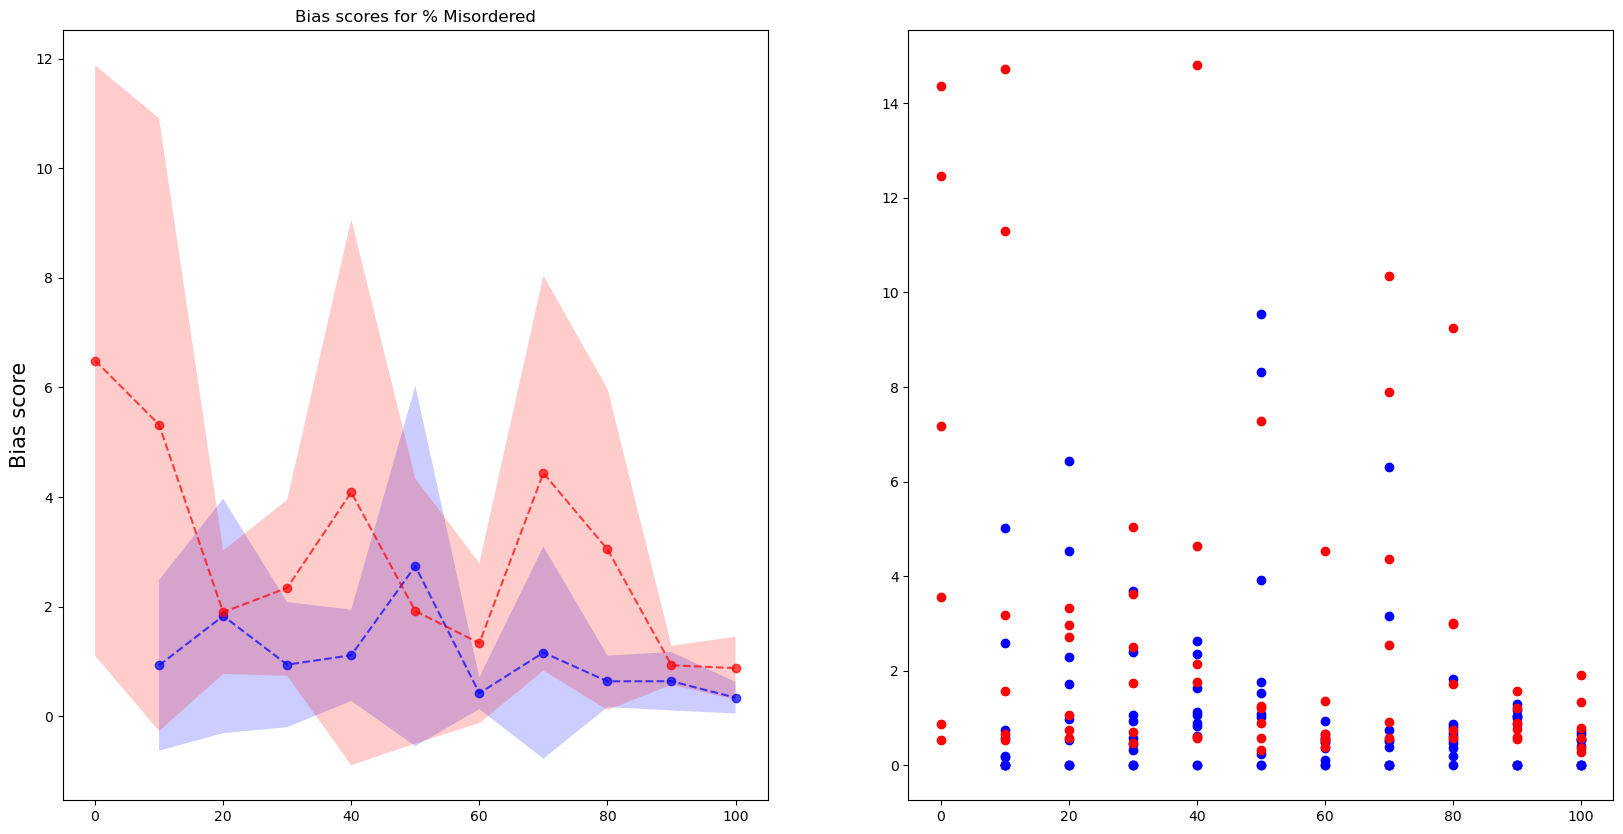

In [423]:

### calculate the largest deviance from expected. 
#How much of total proportion found is attributed to one motif. 
## how muhc of total p[roportion not found is because of one motif



import ast
number = []
prop_seqs_found_individual = []
proportion =[]

current_type = 'swapped_spikes'
for index,type_ in enumerate(df.type):
    if current_type in type_:
        if not np.isnan(df.proportion_found[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [df.proportion_mislabeled[index]*100]
            prop_seqs_found_individual += [ast.literal_eval(df.seqs_found_over_implanted[index])]
            
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    
prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])
        
normalised_bias_score = []
for index,prop in enumerate(proportion):
    if prop > 0:
        prop_seqs = prop_seqs_found_individual[index]
        expected_prop = prop/len(prop_seqs) # expected if all seqs were equal given outcome prop found
        normalised_bias_score  += [((sum(abs(np.array(prop_seqs) - expected_prop))/4) / expected_prop)]
    else:
        normalised_bias_score += [0]
        
group_values = {}
for value, group in zip(normalised_bias_score, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)


fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))


ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'blue', alpha = 0.7)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'blue')
    
    
### decoder

import ast
number = []
prop_seqs_found_individual = []
proportion =[]

current_type = 'swapped_spikes'
for index,type_ in enumerate(decoder_df.type):
    if current_type in type_:
        if not np.isnan(decoder_df.proportion_found[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [decoder_df.proportion_mislabeled[index]*100]
            prop_seqs_found_individual += [ast.literal_eval(decoder_df.seqs_found_over_implanted[index])]
            
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    
prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])
        
normalised_bias_score = []
for index,prop in enumerate(proportion):
    if prop > 0:
        prop_seqs = prop_seqs_found_individual[index]
        expected_prop = prop/len(prop_seqs) # expected if all seqs were equal given outcome prop found
        normalised_bias_score  += [((sum(abs(np.array(prop_seqs) - expected_prop))/4) / expected_prop)]
    else:
        normalised_bias_score += [0]
        
group_values = {}
for value, group in zip(normalised_bias_score, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)


ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'red', alpha = 0.7)


group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='red',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'red')
    
    
ax.set_title('Bias scores for % Misordered')
ax.set_ylabel('Bias score', size = 15)



# Background noise insertion 

{0: 3.3640023932937084, 20: 0.5913859988600559, 40: 0.8796543689697356, 80: 0.9132020092551996, 100: 0.6227075992050982, 200: 0.9295759577957691, 300: 1.0625481547930635, 400: 0.953169757934178, 500: 0.9032365064321886}


C:\Users\Emmett\AppData\Local\Temp\ipykernel_7840\2722317432.py:22: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])
C:\Users\Emmett\AppData\Local\Temp\ipykernel_7840\2722317432.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])


Text(0, 0.5, 'Bias score')

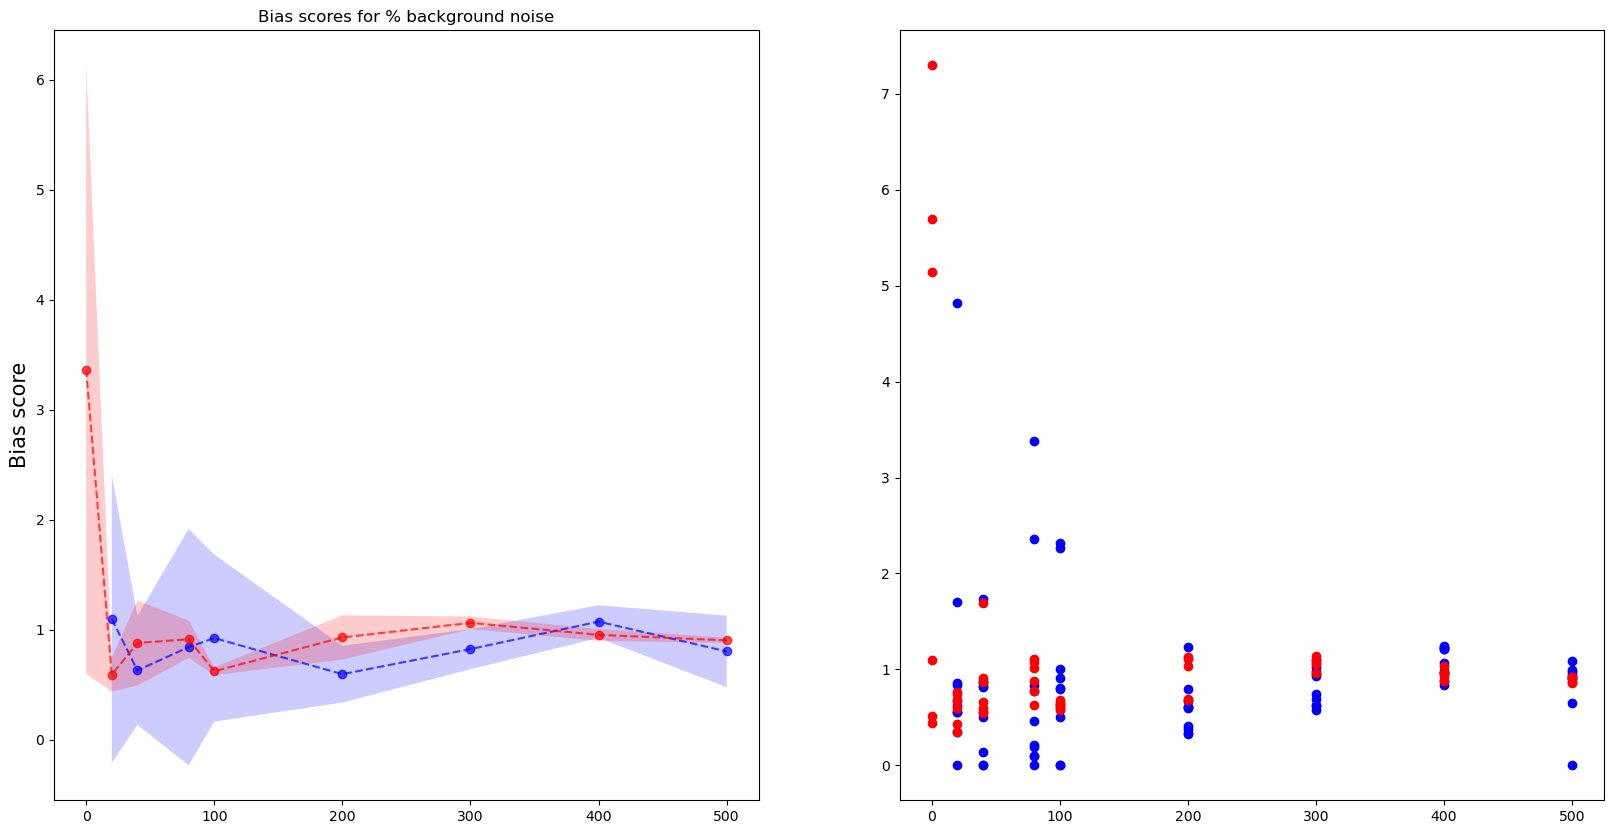

In [424]:

### calculate the largest deviance from expected. 
#How much of total proportion found is attributed to one motif. 
## how muhc of total p[roportion not found is because of one motif



import ast
number = []
prop_seqs_found_individual = []
proportion =[]

current_type = 'background_noise'
for index,type_ in enumerate(df.type):
    if current_type in type_:
        if not np.isnan(df.proportion_found[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [df.proportion_mislabeled[index]*100]
            prop_seqs_found_individual += [ast.literal_eval(df.seqs_found_over_implanted[index])]
            
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    
prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])
        
normalised_bias_score = []
for index,prop in enumerate(proportion):
    if prop > 0:
        prop_seqs = prop_seqs_found_individual[index]
        expected_prop = prop/len(prop_seqs) # expected if all seqs were equal given outcome prop found
        normalised_bias_score  += [((sum(abs(np.array(prop_seqs) - expected_prop))/4) / expected_prop)]
    else:
        normalised_bias_score += [0]
        
group_values = {}
for value, group in zip(normalised_bias_score, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)


fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))


ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'blue', alpha = 0.7)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'blue')
    
    
### decoder

import ast
number = []
prop_seqs_found_individual = []
proportion =[]

current_type = 'background_noise'
for index,type_ in enumerate(decoder_df.type):
    if current_type in type_:
        if not np.isnan(decoder_df.proportion_found[index]):
            number += [int(re.findall(r'\d+', type_)[0])]
            proportion += [decoder_df.proportion_mislabeled[index]*100]
            prop_seqs_found_individual += [ast.literal_eval(decoder_df.seqs_found_over_implanted[index])]
            
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    
prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])
        
normalised_bias_score = []
for index,prop in enumerate(proportion):
    if prop > 0:
        prop_seqs = prop_seqs_found_individual[index]
        expected_prop = prop/len(prop_seqs) # expected if all seqs were equal given outcome prop found
        normalised_bias_score  += [((sum(abs(np.array(prop_seqs) - expected_prop))/4) / expected_prop)]
    else:
        normalised_bias_score += [0]
        
group_values = {}
for value, group in zip(normalised_bias_score, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)


ax.plot(group_means.keys(),group_means.values(), 'o--', color = 'red', alpha = 0.7)


group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(group_means.keys(),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='red',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [x] * len(y)
    ax2.plot(x_,y,'o',color = 'red')
    
ax.set_title('Bias scores for % background noise')
ax.set_ylabel('Bias score', size = 15)


# Warp

136_1_3
148_2_2
149_1_1
178_1_6
178_1_7
178_2_1
178_2_3
178_2_4
178_2_4
269_1_2
270_1_3
136_1_3
148_2_2
149_1_1
178_1_6
178_1_7
178_2_1
{0.03: 0.5465598197879125, 0.1: 1.0664821109987246, 0.2: 3.551756246634028, 0.5: 4.098222584949555, 1.0: 8.53703313816558, 2.0: 0.44956104057268675, 5.0: 0.7347419559730946, 10.0: 1.202222198990319, 20.0: 0.7922752259277389, 30.0: 0.7039716142495646}


C:\Users\Emmett\AppData\Local\Temp\ipykernel_7840\3711710613.py:29: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])
C:\Users\Emmett\AppData\Local\Temp\ipykernel_7840\3711710613.py:93: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])


[Text(0, 0, '0.03'),
 Text(1, 0, '0.1'),
 Text(2, 0, '0.2'),
 Text(3, 0, '0.5'),
 Text(4, 0, '1.0'),
 Text(5, 0, '2.0'),
 Text(6, 0, '5.0'),
 Text(7, 0, '10.0'),
 Text(8, 0, '20.0'),
 Text(9, 0, '30.0')]

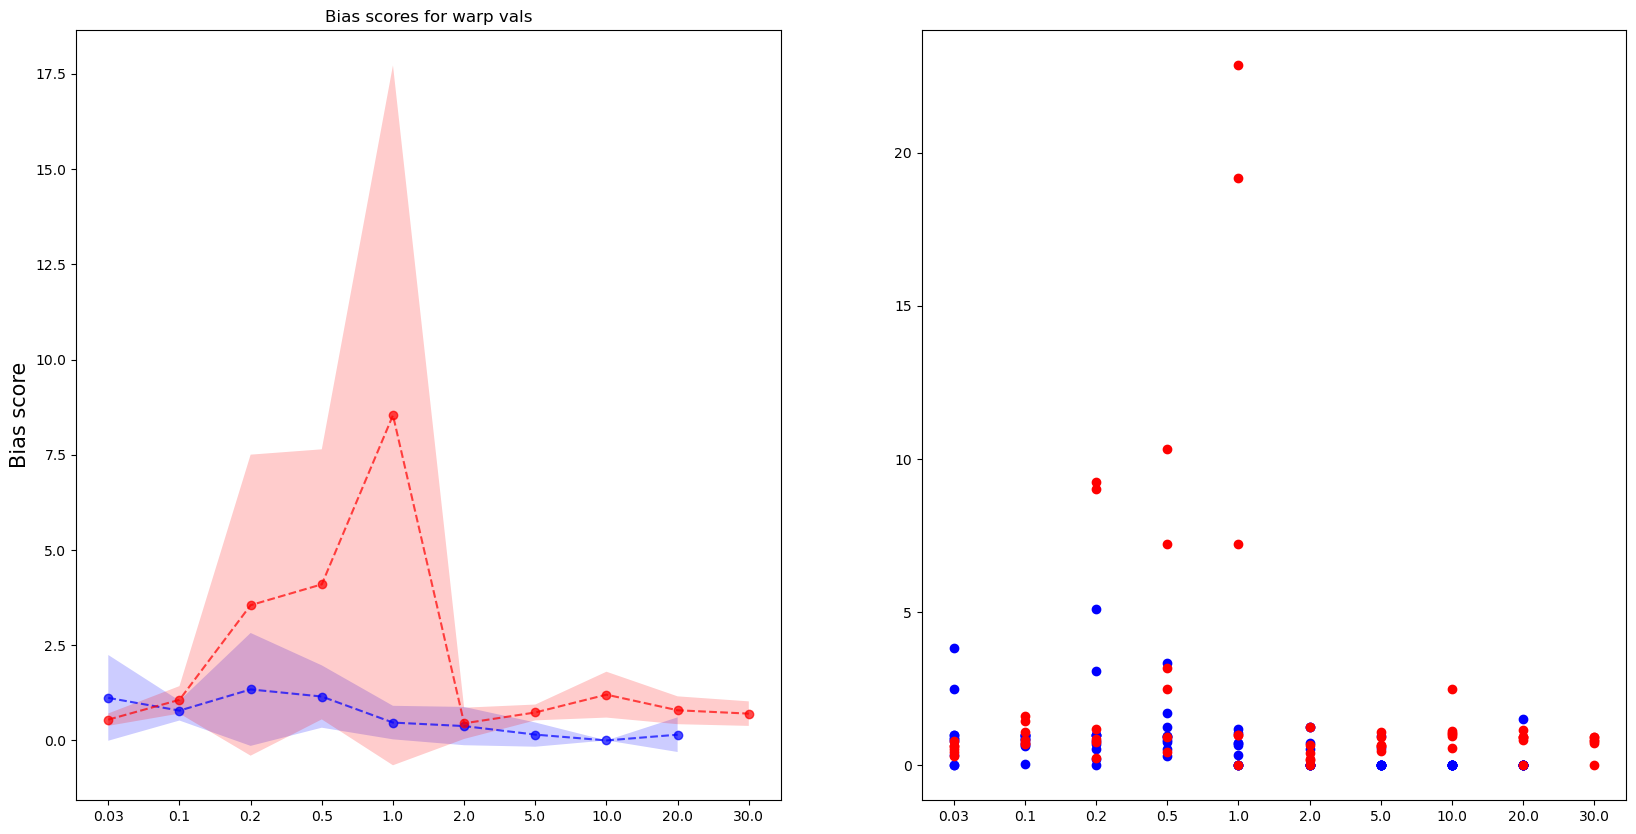

In [425]:

### calculate the largest deviance from expected. 
#How much of total proportion found is attributed to one motif. 
## how muhc of total p[roportion not found is because of one motif



import ast
number = []
prop_seqs_found_individual = []
proportion =[]

current_type = 'warp'
for index,type_ in enumerate(df.type):
    if current_type in type_:
        if not np.isnan(df.proportion_found[index]):
            proportion += [df.proportion_mislabeled[index]*100]
            prop_seqs_found_individual += [ast.literal_eval(df.seqs_found_over_implanted[index])]
            try:
                number += [float(re.findall(r'\d+\.\d+', type_)[0])]
                if float(re.findall(r'\d+\.\d+', type_)[0]) == 0.1:
                    print(df.mouse_implant_recording[index])
            except:
                number += [int(re.findall(r'\d+', type_)[0])]

            
            
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    
prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])
        
normalised_bias_score = []
for index,prop in enumerate(proportion):
    if prop > 0:
        prop_seqs = prop_seqs_found_individual[index]
        expected_prop = prop/len(prop_seqs) # expected if all seqs were equal given outcome prop found
        normalised_bias_score  += [((sum(abs(np.array(prop_seqs) - expected_prop))/4) / expected_prop)]
    else:
        normalised_bias_score += [0]
        
group_values = {}
for value, group in zip(normalised_bias_score, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)


fig, [ax,ax2]= plt.subplots(1, 2,figsize=(20, 10))

labels = list(np.sort(np.unique(number)).astype(str))
ax.plot(np.sort(list(range(0,len(np.unique(labels))))),group_means.values(), 'o--', color = 'blue', alpha = 0.7)

group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(np.sort(list(range(0,len(np.unique(labels))))),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='blue',
    linewidth=1, linestyle='dashdot', antialiased=True)

for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [np.sort(list(range(0,len(np.unique(labels)))))[i]]*len(y)
    ax2.plot(x_,y,'o',color = 'blue')
    
### decoder

import ast
number = []
prop_seqs_found_individual = []
proportion =[]

current_type = 'warp'
for index,type_ in enumerate(decoder_df.type):
    if current_type in type_:
        if not np.isnan(decoder_df.proportion_found[index]):
            proportion += [decoder_df.proportion_mislabeled[index]*100]
            prop_seqs_found_individual += [ast.literal_eval(decoder_df.seqs_found_over_implanted[index])]
            try:
                number += [float(re.findall(r'\d+\.\d+', type_)[0])]
                if float(re.findall(r'\d+\.\d+', type_)[0]) == 0.1:
                    print(df.mouse_implant_recording[index])
            except:
                number += [int(re.findall(r'\d+', type_)[0])]
            
proportion = list(np.array(proportion)[np.argsort(number)])
number = np.array(number)[np.argsort(number)]    
prop_seqs_found_individual = list(np.array(prop_seqs_found_individual)[np.argsort(number)])
   

normalised_bias_score = []
for index,prop in enumerate(proportion):
    if prop > 0:
        prop_seqs = prop_seqs_found_individual[index]
        expected_prop = prop/len(prop_seqs) # expected if all seqs were equal given outcome prop found
        normalised_bias_score  += [((sum(abs(np.array(prop_seqs) - expected_prop))/4) / expected_prop)]
    else:
        normalised_bias_score += [0]
        
group_values = {}
for value, group in zip(normalised_bias_score, number):
    if group in group_values:
        group_values[group].append(value)
    else:
        group_values[group] = [value]
group_means = {}
group_std ={}
for group, values in group_values.items():
    group_means[group] = statistics.mean(values)
    group_std[group] = np.std(values)
print(group_means)

labels = list(np.sort(np.unique(number)).astype(str))
ax.plot(np.sort(list(range(0,len(np.unique(labels))))),group_means.values(), 'o--', color = 'red', alpha = 0.7)


group_means_array = np.array(list(group_means.values()))
group_std_array = np.array(list(group_std.values()))
upper = group_means_array + group_std_array
lower = group_means_array - group_std_array
ax.fill_between(np.sort(list(range(0,len(np.unique(labels))))),(lower),(upper),
    alpha=0.2, edgecolor='None', facecolor='red',
    linewidth=1, linestyle='dashdot', antialiased=True)


for i,x in enumerate(group_values.keys()):
    y = list(group_values.values())[i]
    x_ = [np.sort(list(range(0,len(np.unique(labels)))))[i]]*len(y)
    ax2.plot(x_,y,'o',color = 'red')
    
ax.set_title('Bias scores for warp vals')
ax.set_ylabel('Bias score', size = 15)


ax.set_xticks(range(0,len(labels)))
ax.set_xticklabels(labels)

ax2.set_xticks(range(0,len(labels)))
ax2.set_xticklabels(labels)

In [426]:
type_

'random_insertion'